In [1]:
import starry
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import pymc3.math as pmm
import pymc3_ext as pmx
import exoplanet
from starry_process import StarryProcess, MCMCInterface
from starry_process.math import cho_factor, cho_solve
import starry_process 
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding

theano.graph.opt.EquilibriumOptimizer
import aesara_theano_fallback.tensor as tt
from theano.tensor.slinalg import cholesky
from corner import corner
import arviz as az
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
from tqdm import tqdm
from theano.tensor.random.utils import RandomStream
import scipy.linalg as sl
import scipy.stats as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import lightkurve as lk

starry.config.quiet = True
np.random.seed(1)

import warnings

# Ignore all warnings (not recommended, might hide other important warnings)
warnings.filterwarnings("ignore")

# Ignore specific warning by type
warnings.filterwarnings("ignore", message="Cannot construct a scalar test value from a test value with no size")

# Set logging level to ignore these warnings (recommended)
import logging
logger = logging.getLogger("theano.tensor.opt")
logger.setLevel(logging.ERROR)


WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/Users/sabina/miniconda3/envs/starry-debug/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sabina/miniconda3/envs/starry-debug/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/sabina/.lightkurve/cache. Please move all the files in the legacy directory /Users/sabina/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/refer

In [2]:
import sys
sys.path.insert(1, '/Users/sabina/Desktop/GitHub/starry/scripts')

from Linear_starry_starry_process import LinearInterpolatedStarryStarryProcess

## Helper Distribution functions

In [3]:
def Inclination(name, testval=30):
    """
    An isotropic distribution for inclination angles (in degrees).
    
    """
    def logp(x):
        return tt.log(np.pi / 180 * tt.sin(x * np.pi / 180))

    def random(*args, **kwargs):
        return tt.arccos(pm.Uniform.dist(0, 1).random(*args, **kwargs)) * 180 / np.pi

    return pm.DensityDist(
        name,
        logp,
        random=random,
        initval=testval,
    )

def Angle(*args, **kwargs):
    """
    A uniform distribution for angles in [-180, 180).
    
    """
    if kwargs.get("testval", None) is not None:
        kwargs["testval"] *= np.pi / 180
    return 180 / np.pi * pmx.Angle(*args, **kwargs)

def Planet_Inc(name, *args, **kwargs):
    bmax = params[name].get('bmax')
    b = pm.Uniform('b', -bmax, bmax)
    planet_inc = pm.Deterministic(name, 180.0/np.pi*np.arccos(b))
    
    return planet_inc

def xyz_transform(x_, y_, z_):
    x = x_
    y = (np.sqrt(2)/2) * (z_ + y_)
    z = (np.sqrt(2)/2) * (z_ - y_)

    return x, y, z

def xyz_transform_back(x, y, z):
    x_ = x
    y_ = (np.sqrt(2)/2) * (y - z)
    z_ = (np.sqrt(2)/2) * (y + z)

    return x_, y_, z_

def Stellar_Ori():
    stellar_ori_x_ = pm.Normal('stellar_ori_x_', mu=0, sigma=1, testval=1)
    stellar_ori_y_ = pm.Normal('stellar_ori_y_', mu=0, sigma=1, testval=1)
    stellar_ori_z_ = pm.HalfNormal('stellar_ori_z_', sigma=1, testval=1)

    stellar_ori_x, stellar_ori_y, stellar_ori_z = xyz_transform(stellar_ori_x_, stellar_ori_y_, stellar_ori_z_)

    stellar_obl = pm.Deterministic('star.obl', 180.0/np.pi*tt.arctan2(stellar_ori_y, stellar_ori_x))
    stellar_inc = pm.Deterministic('star.inc', 180.0/np.pi*tt.arccos(stellar_ori_z / tt.sqrt(tt.square(stellar_ori_x) + tt.square(stellar_ori_y) + tt.square(stellar_ori_z))))
    
    return stellar_inc, stellar_obl
    # if "inc" in name:
    #     return stellar_inc
    
    # elif "obl" in name:
    #     return stellar_obl

def Period(name, *args, **kwargs):
    Ttotal = t[-1] - t[0]
    frac_bounds = params[name].get('frac_bounds')

    if kwargs.get("testval", None) is not None:
        trueval = kwargs["testval"]

    def logp(trueval, frac_bounds):
        return pm.Uniform(name+'logp',tt.log(trueval) + np.log1p(-frac_bounds), tt.log(trueval) + np.log1p(frac_bounds))

    period = pm.Deterministic(name, tt.exp(logp(trueval, frac_bounds)))

    return period

def Logarithmic(name, *args, **kwargs):
    if kwargs.get("testval", None) is not None:
        trueval = kwargs["testval"]
    log_rp = pm.Uniform(name+'log', tt.log(trueval/2), tt.log(2*trueval))
    rp = pm.Deterministic(name, tt.exp(log_rp))

    return rp

# Shorthand for the usual Uniform distribution
Uniform = pm.Uniform

In [4]:
def gp_model(t, flux, err, num_maps, params):

    # Helper function to instantiate parameters
    def parameter(name):
        param = params[name]
        if param.get("free", False):
            args = param.get("args", [])
            kwargs = param.get("kwargs", {})
            testval = param.get("testval", param["truth"])
            return param["dist"](name, *args, testval=testval, **kwargs)
            
        else:
            return param["truth"]
    
    
    starry.config.lazy = True
    
    with pm.Model() as model:

        prot = parameter('star.prot')

        porb = parameter('planet.porb')
        t0 = parameter('planet.t0')
        rp = parameter('planet.r')
        planet_inc = parameter('planet.inc')
        mp = parameter('planet.m')
        ecc = parameter('planet.ecc')
        Omega = parameter('planet.Omega')

        map_model = starry.Map(ydeg=15, udeg=2)

        stellar_inc, stellar_obl = Stellar_Ori()
        # map_model.inc = parameter('star.inc')
        # map_model.obl = parameter('star.obl')
        map_model.inc = stellar_inc
        map_model.obl = stellar_obl
        
        map_model[1] = parameter('star.u1')
        map_model[2] = parameter('star.u2')
        
        pri_model = starry.Primary(map_model, 
            r=parameter('star.r'), 
            m=parameter('star.m'), 
            prot=prot)

        sec_model = starry.kepler.Secondary(starry.Map(0,0), 
            t0=t0, 
            r=rp, 
            m=mp, 
            porb=porb, 
            ecc=ecc, 
            Omega=Omega, 
            inc=planet_inc,)
    
        sys_model = starry.System(pri_model, sec_model)

        # Instantiate the GP
        sp_model = StarryProcess(
            # mu=parameter("gp.mu"),
            # sigma=parameter("gp.sigma"),
            a=parameter("gp.a"),
            b=parameter("gp.b"),
            r=parameter("gp.r"),
            c=parameter("gp.c"),
            n=parameter("gp.n"),
            ydeg=15,
            udeg=2,
            marginalize_over_inclination=False,  
        )
        
        K00 = 0.
        K01 = 10.
        K10 = np.log(0.5)
        K11 = 10.
        alpha = tt.exp(K00 + (K10 - K00) * sp_model.a)
        beta = tt.exp(K10 + (K11 - K10) * sp_model.b) 

        pm.Deterministic('sp.mu', alpha / (alpha + beta) * 180 / np.pi)
        pm.Deterministic('sp.var', alpha * beta / (tt.square(alpha + beta) * (alpha + beta + 1)) * 180 / np.pi)

        ssp_model = LinearInterpolatedStarryStarryProcess(sys_model, sp_model, num_maps=num_maps)

        # ssp_model._compute(t, np.zeros_like(t), np.ones_like(t))
        ssp_model._compute(t, flux, err)

        pm.Deterministic('flux_model', tt.dot(ssp_model.design_matrix, ssp_model._a))
        pm.Deterministic('y_model', ssp_model._a)

        pm.Potential('marginal_likelihood', ssp_model.marginal_likelihood(t, flux, err))
        
        return model

In [5]:
def bin_out_of_transit(t, flux, err, params, dt=0.06, binsize=30):
    """
    Bin the out of transit points to speed things up.
    
    """
    # Find in-transit and out-of-transit points
    idx = np.zeros(len(t), dtype=bool)
    ntransits = int(np.ceil(t[-1] / params["planet.porb"]["truth"]))
    for n in range(ntransits):
        t0 = params["planet.t0"]["truth"] + n * params["planet.porb"]["truth"]
        idx |= ((t > t0 - dt) & (t < t0 + dt))
    t_in = t[idx]
    f_in = flux[idx]
    t_out = t[~idx]
    f_out = flux[~idx]

    # Make the size of the out-of-transit array divisible by binsize
    # so we can bin by simple array reshaping
    trim = len(t_out) % binsize
    t_out = t_out[:-trim]
    f_out = f_out[:-trim]

    # We need to be careful not to bin *across* the transit, so
    # let's NaN-out points right _before_ each transit
    f_out[np.where(np.diff(t_out) > 0.1)] = np.nan

    # Bin the out-of-transit data
    t_out = t_out.reshape(-1, binsize).mean(axis=1)
    f_out = f_out.reshape(-1, binsize).mean(axis=1)

    # Remove any nans (the averages *across* transits)
    idx = np.isnan(f_out)
    t_out = t_out[~idx]
    f_out = f_out[~idx]

    # Error arrays
    e_in = err[0] * np.ones_like(t_in)
    e_out = (err[0] / np.sqrt(binsize)) * np.ones_like(t_out)

    # Sort and merge the arrays
    t_ = np.concatenate((t_in, t_out))
    f_ = np.concatenate((f_in, f_out))
    e_ = np.concatenate((e_in, e_out))
    idx = np.argsort(t_)
    t_ = t_[idx]
    flux_ = f_[idx]
    err_ = e_[idx]

    return t_, flux_, err_

## Generate a light curve

In [6]:
# True parameters & priors
params = {
    "planet.inc": {"truth": 90.0, "dist": Planet_Inc},
    "planet.ecc": {"truth": 0.0, "dist": Uniform, "args": [0.0, 0.4]},
    "planet.Omega": {"truth": 0.0, "dist": Angle},
    "planet.porb": {"truth": 4.88, "dist": Period},
    "planet.t0": {"truth": 0.0, "dist": Uniform, "args": [-0.2, 0.2]},
    "planet.r": {"truth": 0.04, "dist": Logarithmic},
    "planet.m": {"truth": 1e-3, "dist": Uniform, "args": [0.0001, 0.002]},

    "star.inc": {"truth": 90, "dist": Stellar_Ori},
    "star.m": {"truth": 1, "dist": Uniform, "args": [0.4, 1]},
    "star.u1": {"truth": 0.4, "dist": Uniform, "args": [0.0, 0.6]},
    "star.u2": {"truth": 0.26, "dist": Uniform, "args": [0.0, 0.4]},
    "star.prot": {"truth": 30, "dist": Period},
    "star.obl": {"truth": -30.0, "dist": Stellar_Ori},
    "star.r": {"truth": 1, "dist": Uniform, "args": [0.1, 1]},

    "gp.r": {"truth": 20, "dist": Uniform, "args": [5.0, 25.0]},
    "gp.c": {"truth": 0.5, "dist": Uniform, "args": [0.01, 1]},
    "gp.n": {"truth": 3, "dist": Uniform, "args": [0, 10]},
    "gp.a": {"truth": 0.2, "dist": Uniform, "args": [0., 1.]},
    "gp.b": {"truth": 0.06, "dist": Uniform, "args": [0., 1.]},
    # "gp.mu": {"truth": 20., "dist": Uniform, "args": [0.0, 70.]},
    # "gp.sigma": {"truth": 5., "dist": Uniform, "args": [0.0, 10.]}
}
num_maps = 3
nlm = 256

rng = np.random.default_rng(302592346730275158208684369480422136411)

map = starry.Map(15, 2)
map.inc = params["star.inc"]["truth"]
map.obl = params["star.obl"]["truth"]
map[1] = params["star.u1"]["truth"]
map[2] = params["star.u2"]["truth"]
star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
planet = starry.Secondary(
    starry.Map(0,0),
    inc=params["planet.inc"]["truth"],
    ecc=params["planet.ecc"]["truth"],
    Omega=params["planet.Omega"]["truth"],
    porb=params["planet.porb"]["truth"],
    t0=params["planet.t0"]["truth"],
    r=params["planet.r"]["truth"],
    m=params["planet.m"]["truth"],
    prot=1.0
)

sys = starry.System(star, planet)

sp = StarryProcess(
    # mu=params["gp.mu"]["truth"],
    # sigma=params["gp.sigma"]["truth"],
    a=params["gp.a"]["truth"],
    b=params["gp.b"]["truth"],
    r=params["gp.r"]["truth"],
    c=params["gp.c"]["truth"],
    n=params["gp.n"]["truth"],
    marginalize_over_inclination=False, 
    ydeg=15, 
    udeg=2,
    seed=rng.integers(0, 1<<32)
)

ys_true = np.zeros((num_maps, nlm))
for i in range(num_maps):
    ys_true[i, :] = sp.sample_ylm().eval()[0, :]
ys_true[0][0] = 1.
ys_true[1][0] = 1.02
ys_true[2][0] = 1.03

t = np.arange(0, 90, 2 / 24 / 60)
nt=len(t)

Ttotal = t[-1] - t[0]

# Setting the priors
# fraction bounds for period priors
prot_frac_bounds = min(params['star.prot']['truth']/Ttotal/100, 0.25)
porb_frac_bounds = min(params['planet.porb']['truth']/Ttotal/100, 0.25)

# Let's add this parameter to the parameter dictionary as a prior
params['star.prot']['frac_bounds'] = prot_frac_bounds
params['planet.porb']['frac_bounds'] = porb_frac_bounds

# semi-major axis
a = (params['star.m']['truth']*np.square(params['planet.porb']['truth']/365.25))**(1/3) * 215.03 # Solar radii
# impact parameter
bmax = params['star.r']['truth'] / a

# Let's add this parameter to the parameter dictionary as a prior
params['planet.inc']['bmax'] = bmax

In [7]:
from itertools import tee

def pairwise(iterable):
    "s -> (s0,s1), (s1,s2), (s2, s3), ..."
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

theta = (360 * t / sys.bodies[0].prot) % 360
MM = sys.bodies[0].map.design_matrix(
    xo = sys.position(t)[0][1,:],
    yo = sys.position(t)[1][1,:],
    zo = sys.position(t)[2][1,:],
    ro = sys.bodies[1].r,
    theta = theta
    ).eval()

total_time = t[-1] - t[0]
time_interval = total_time / (num_maps - 1)
nt = len(t)
M = np.zeros((nt, MM.shape[1] * num_maps))

sections = [t[0] + i * time_interval for i in range(num_maps)]

for i, (t_lo, t_hi) in enumerate(pairwise(sections)):
    idx = (t >= t_lo) & (t <= t_hi)
    if i>0:
        idx[np.where(idx == True)[0][0]-1] = True
    
    t_section = t[idx]
    MM_section = MM[idx]
    
    phi = (t_section - t_hi) / (t_lo - t_hi)
    n = phi.shape[0]
    coeffs = np.zeros((n, num_maps))
    coeffs[:, i] = phi
    coeffs[:, i + 1] = 1 - phi
    
    M[idx, :] = np.reshape(MM_section[:, None, :] * coeffs[:, :, None], (n, -1))

In [8]:
flux_true = M @ np.concatenate((ys_true))
sigma_flux = 1e-4*np.ones_like(flux_true)

flux_obs = flux_true + sigma_flux*rng.normal(size=nt)

In [9]:
ssp = LinearInterpolatedStarryStarryProcess(sys, sp, num_maps)

In [10]:
ssp.marginal_likelihood(t, flux_obs, sigma_flux).eval()

array(786205.23573762)

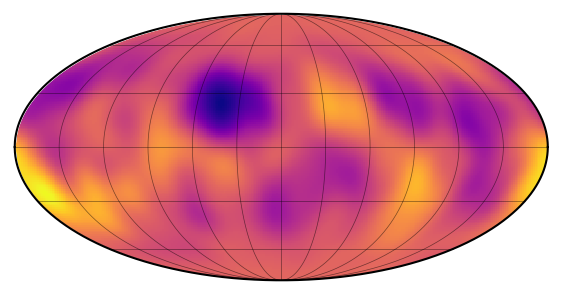

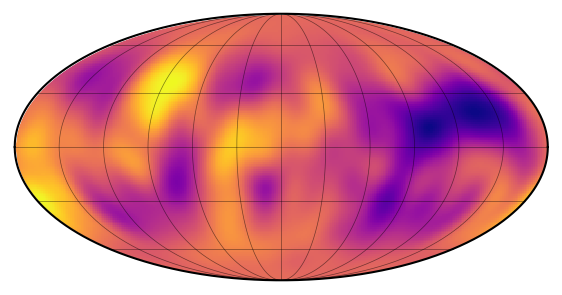

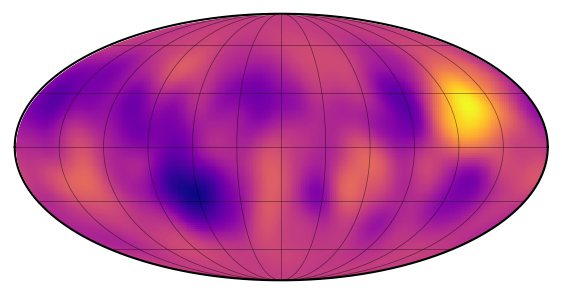

In [11]:
for i in range(num_maps):
    sp.visualize(ssp._a.eval()[i*nlm:(i+1)*nlm])

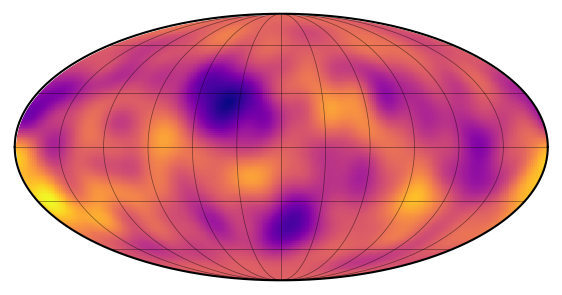

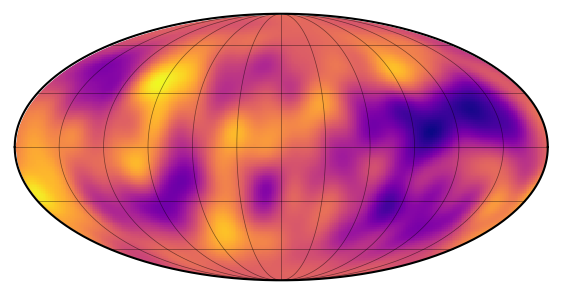

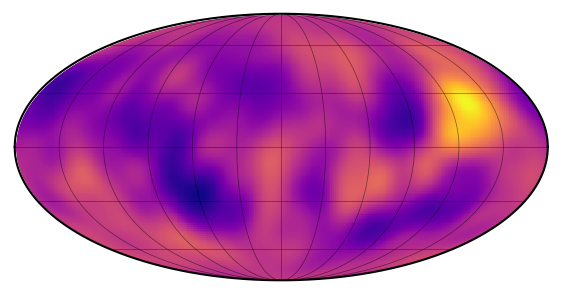

In [12]:
for y in ys_true:
    sp.visualize(y)

Text(0, 0.5, 'normalized flux')

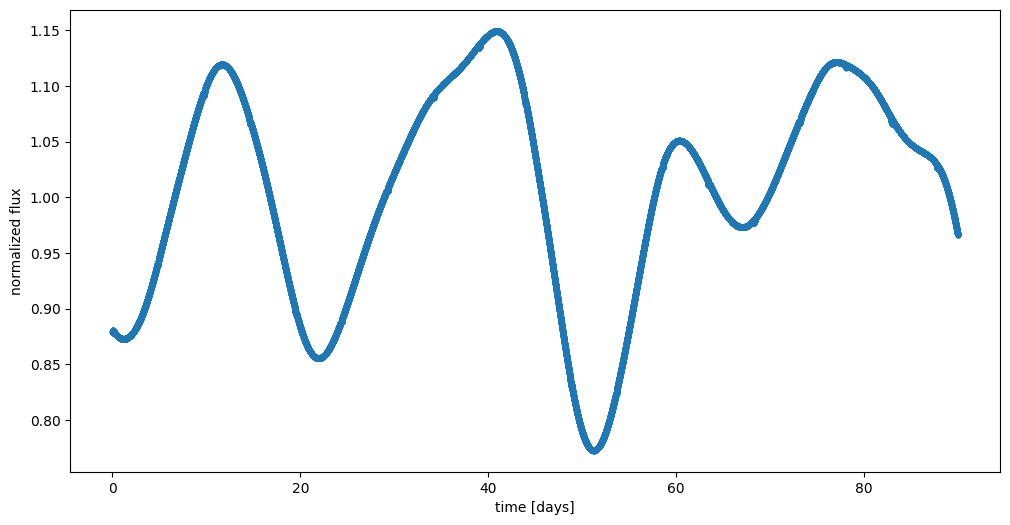

In [13]:
plt.figure(figsize=(12,6))
plt.plot(t, flux_true, color='k')
plt.errorbar(t, flux_obs, yerr=sigma_flux, fmt='.')
plt.xlabel('time [days]')
plt.ylabel('normalized flux')

<ErrorbarContainer object of 3 artists>

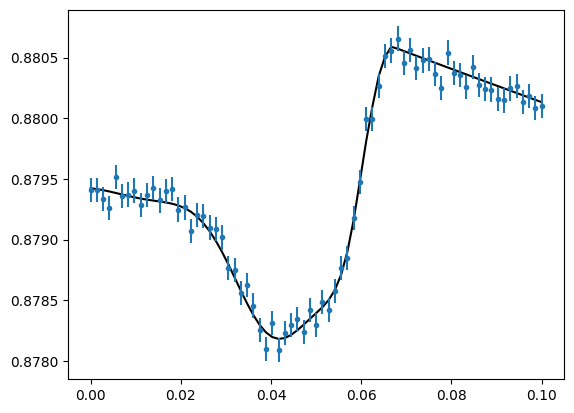

In [14]:
sel = np.abs(t) < 1/10
plt.plot(t[sel], flux_true[sel], color='k')
plt.errorbar(t[sel], flux_obs[sel], yerr=sigma_flux[sel], fmt='.')

In [15]:
t_, flux_, sigma_flux_ = bin_out_of_transit(t, flux_obs, sigma_flux, params, binsize=400)

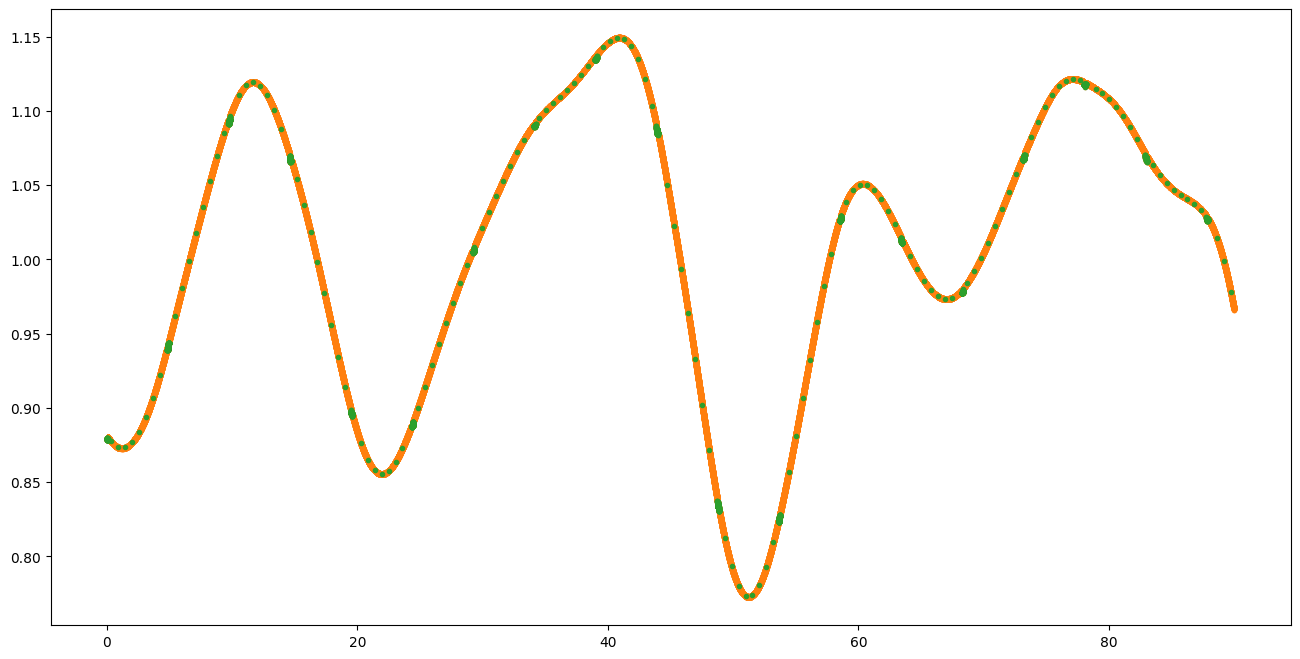

In [16]:
plt.figure(figsize=(16,8))
plt.plot(t, flux_true)
plt.plot(t, flux_obs, '.')
plt.plot(t_, flux_, '.')
# plt.xlim(18, 20)

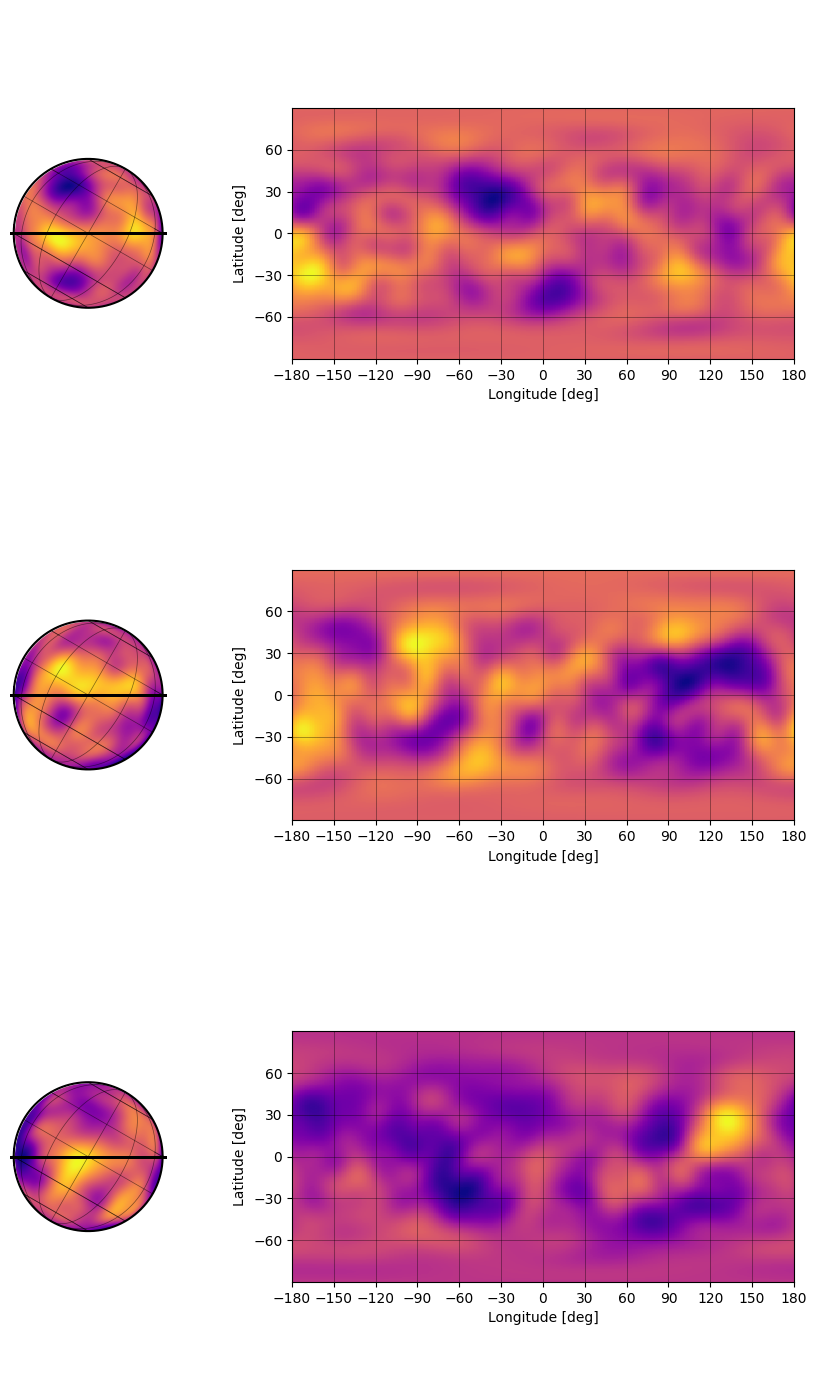

In [17]:
xo, yo, zo = sys.position(t)
xo = xo.eval()[1]
yo = yo.eval()[1]
zo = zo.eval()[1]
theta = (360 * t / params["star.prot"]["truth"]) % 360
fig, ax = plt.subplots(3, 2, figsize=(10, 14))
for i, y in enumerate(ys_true):
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
    ax[i][0].plot(xo[idx], yo[idx], "k.", ms=1);
    ax[i][0].set_aspect(1)
    ax[i][0].axis("off")
    map[:, :] = y
    map.show(ax=ax[i][0])
    ax[i][0].set_ylim(-3, 3)
    idx = (zo > 0) & (xo ** 2 + yo ** 2 < 1)
    lat = 180 / np.pi * np.arcsin(yo[idx])
    lon = 180 / np.pi * np.arcsin(xo[idx] / np.sqrt(1 - yo[idx] ** 2)) - theta[idx]
    lon = (lon + 180) % 360 - 180
    mask = np.append(np.array(lon[1:] > lon[:-1], dtype=float), 0)
    mask[mask == 1] = np.nan
    map.show(ax=ax[i][1], projection="rect")
    ax[i][1].plot(lon, lat + mask, "k-");
plt.tight_layout()
# plt.savefig("figures/experiment-2-true-map.pdf", bbox_inches="tight", dpi=300)

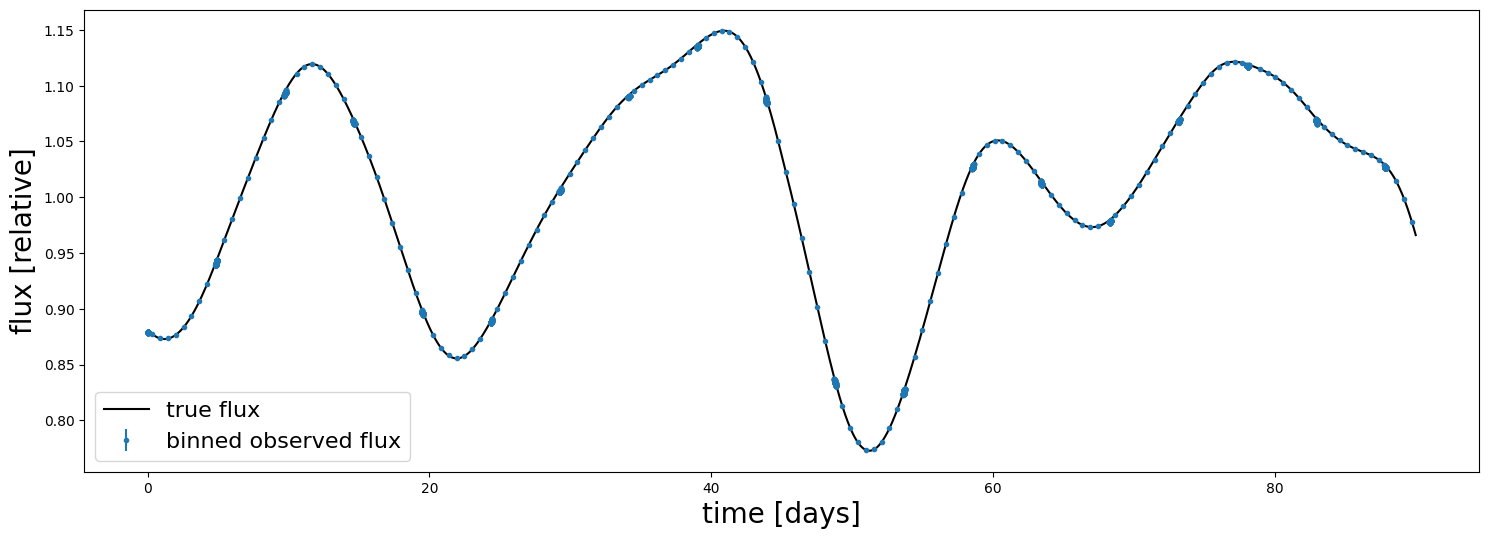

In [18]:
plt.figure(figsize=(18,6))
plt.plot(t, flux_true, color='k', label='true flux')
plt.errorbar(t_, flux_, yerr=sigma_flux_, fmt='.', color='C0', label='binned observed flux')
plt.ylabel("flux [relative]", fontsize=20)
plt.xlabel("time [days]", fontsize=20)
plt.legend(fontsize=16);
# plt.savefig("figures/experiment-1-lc.pdf", bbox_inches="tight", dpi=300)
# plt.xlim(24.2,24.6)
# plt.ylim(0.925,1.)

In [19]:
t_.shape

(1739,)

In [20]:
num_maps=3
theta = (360 * t_ / sys.bodies[0].prot) % 360
MM = sys.bodies[0].map.design_matrix(
    xo = sys.position(t_)[0][1,:],
    yo = sys.position(t_)[1][1,:],
    zo = sys.position(t_)[2][1,:],
    ro = sys.bodies[1].r,
    theta = theta
    ).eval()

totaltime = t_[-1] - t_[0]
time_interval = total_time / (num_maps - 1)
nt = len(t_)
M = np.zeros((nt, MM.shape[1] * num_maps))

def find_nearest(array, value):
    return (np.abs(array - value)).argmin()

section_indices = [0] + [find_nearest(t_, t_[0] + i * total_time / (num_maps - 1)) for i in range(1, num_maps)]
sections = t_[section_indices]

for i, (t_lo, t_hi) in enumerate(pairwise(sections)):
    idx = (t_ >= t_lo) & (t_ <= t_hi)  

    t_section = t_[idx]
    MM_section = MM[idx]
    print(i, t_section[0], t_section[-1], t_section.shape)

    phi = (t_section - t_lo) / (t_hi - t_lo)

    n = phi.shape[0]
    coeffs = np.zeros((n, num_maps))
    coeffs[:, i] = 1. - phi  
    coeffs[:, i + 1] = phi  
    M[idx, :] = np.reshape(MM_section[:, None, :] * coeffs[:, :, None], (n, -1))

0 0.0 44.750694444444434 (891,)
1 44.750694444444434 89.72013888888887 (849,)


In [21]:
M.shape

(1739, 768)

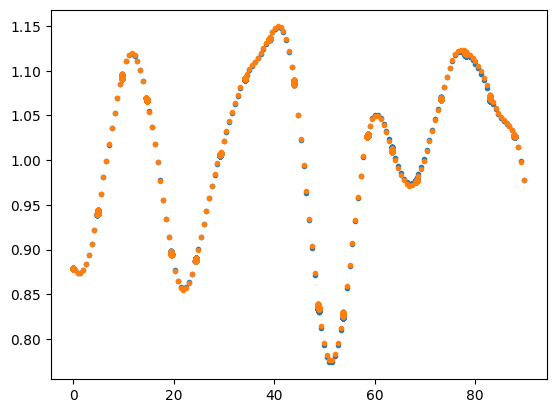

In [22]:
plt.plot(t_, flux_, '.')
plt.plot(t_, M @ np.concatenate((ys_true)), '.')
# plt.plot(t_, sys.design_matrix(t_)[:,:-1].eval() @ ys_true[0])
# plt.xlim(0,20)
# plt.ylim(0.97,0.98)
# plt.axvline(44.68124999999999)

In [23]:
K00 = 0.
K01 = 10.
K10 = np.log(1/2)
K11 = 10.
alpha = np.exp(K00 + (K10 - K00) * params['gp.a']['truth'])
beta = np.exp(K10 + (K11 - K10) * params['gp.b']['truth']) 

# alpha = np.exp(K00 + (K10 - K00) * 0.2)
# beta = np.exp(K10 + (K11 - K10) * 0.06) 

sp_mu = alpha / (alpha + beta) * 180 / np.pi 
sp_var = alpha * beta / (np.square(alpha + beta) * (alpha + beta + 1)) * 180 / np.pi

In [24]:
sp_mu

27.401475676130104

# Inference

In [29]:
# Set some free params & get the model
p = dict(params)

p['star.prot']['free'] = True
p['star.obl']['free'] = True
p['star.inc']['free'] = True

p['planet.porb']['free'] = True
p['planet.t0']['free'] = True
p['planet.r']['free'] = True
p['planet.inc']['free'] = True

p['star.u1']['free'] = True
p['star.u2']['free'] = True

p['gp.c']['free'] = True
# p['gp.mu']['free'] = True
# p['gp.sigma']['free'] = True
p['gp.a']['free'] = True
p['gp.b']['free'] = True
p['gp.r']['free'] = True
p['gp.n']['free'] = True

free = [x for x in p.keys() if p[x].get("free", False)]
model = gp_model(t_, flux_, sigma_flux_, num_maps=num_maps, params=p)

In [30]:
# Optimize
with model:
    map_soln = pmx.optimize()
    for x in free:
        print(f"{x}: {map_soln[x]} {[params[x]['truth']]}")

optimizing logp for variables: [gp.n, gp.c, gp.r, gp.b, gp.a, star.u2, star.u1, stellar_ori_z_, stellar_ori_y_, stellar_ori_x_, b, planet.rlog, planet.t0, planet.porblogp, star.protlogp]



planet.inc: 90.08067951038167 [90.0]
planet.porb: 4.879979557579509 [4.88]
planet.t0: 0.0005504977999070404 [0.0]
planet.r: 0.03991398783437798 [0.04]
star.inc: 90.31932388241701 [90]
star.u1: 0.5382412503127502 [0.4]
star.u2: 0.13479716330576144 [0.26]
star.prot: 30.0006206161475 [30]
star.obl: 31.033798502721606 [-30.0]
gp.r: 19.06005685667855 [20]
gp.c: 0.5371116764102194 [0.5]
gp.n: 2.5335976731095937 [3]
gp.a: 0.2147328659167276 [0.2]
gp.b: 0.0859882272530485 [0.06]


message: Desired error not necessarily achieved due to precision loss.
logp: 20153.312021343234 -> 20350.058764626592


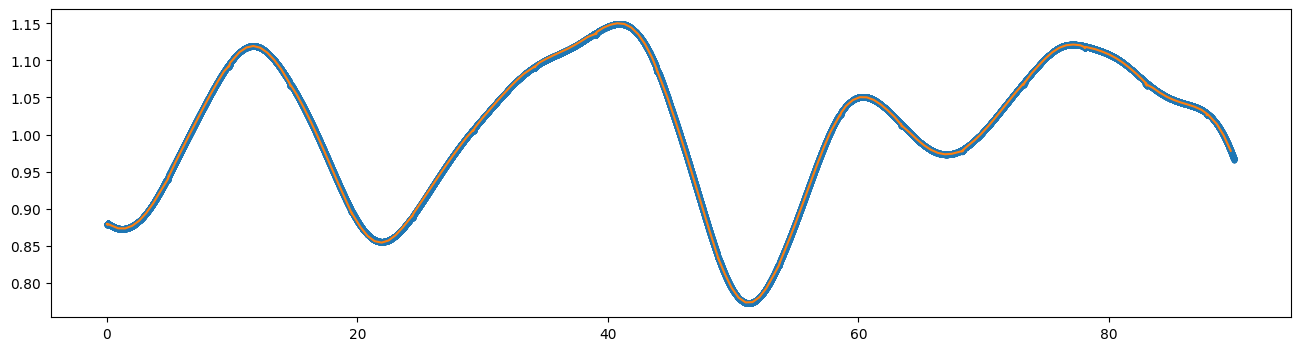

In [31]:
plt.figure(figsize=(16,4))
plt.plot(t, flux_obs, '.')
plt.plot(t_, map_soln['flux_model'])
# plt.xlim(29,30)

In [32]:
with model:
    trace = pmx.sample(
        tune=250,
        draws=500,
        start=map_soln,
        chains=1,
        cores=4,
        target_accept=0.9,
        return_inferencedata=False,
    )

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Sequential sampling (1 chains in 1 job)
NUTS: [gp.n, gp.c, gp.r, gp.b, gp.a, star.u2, star.u1, stellar_ori_z_, stellar_ori_y_, stellar_ori_x_, b, planet.rlog, planet.t0, planet.porblogp, star.protlogp]


Sampling 1 chain for 250 tune and 500 draw iterations (250 + 500 draws total) took 135824 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


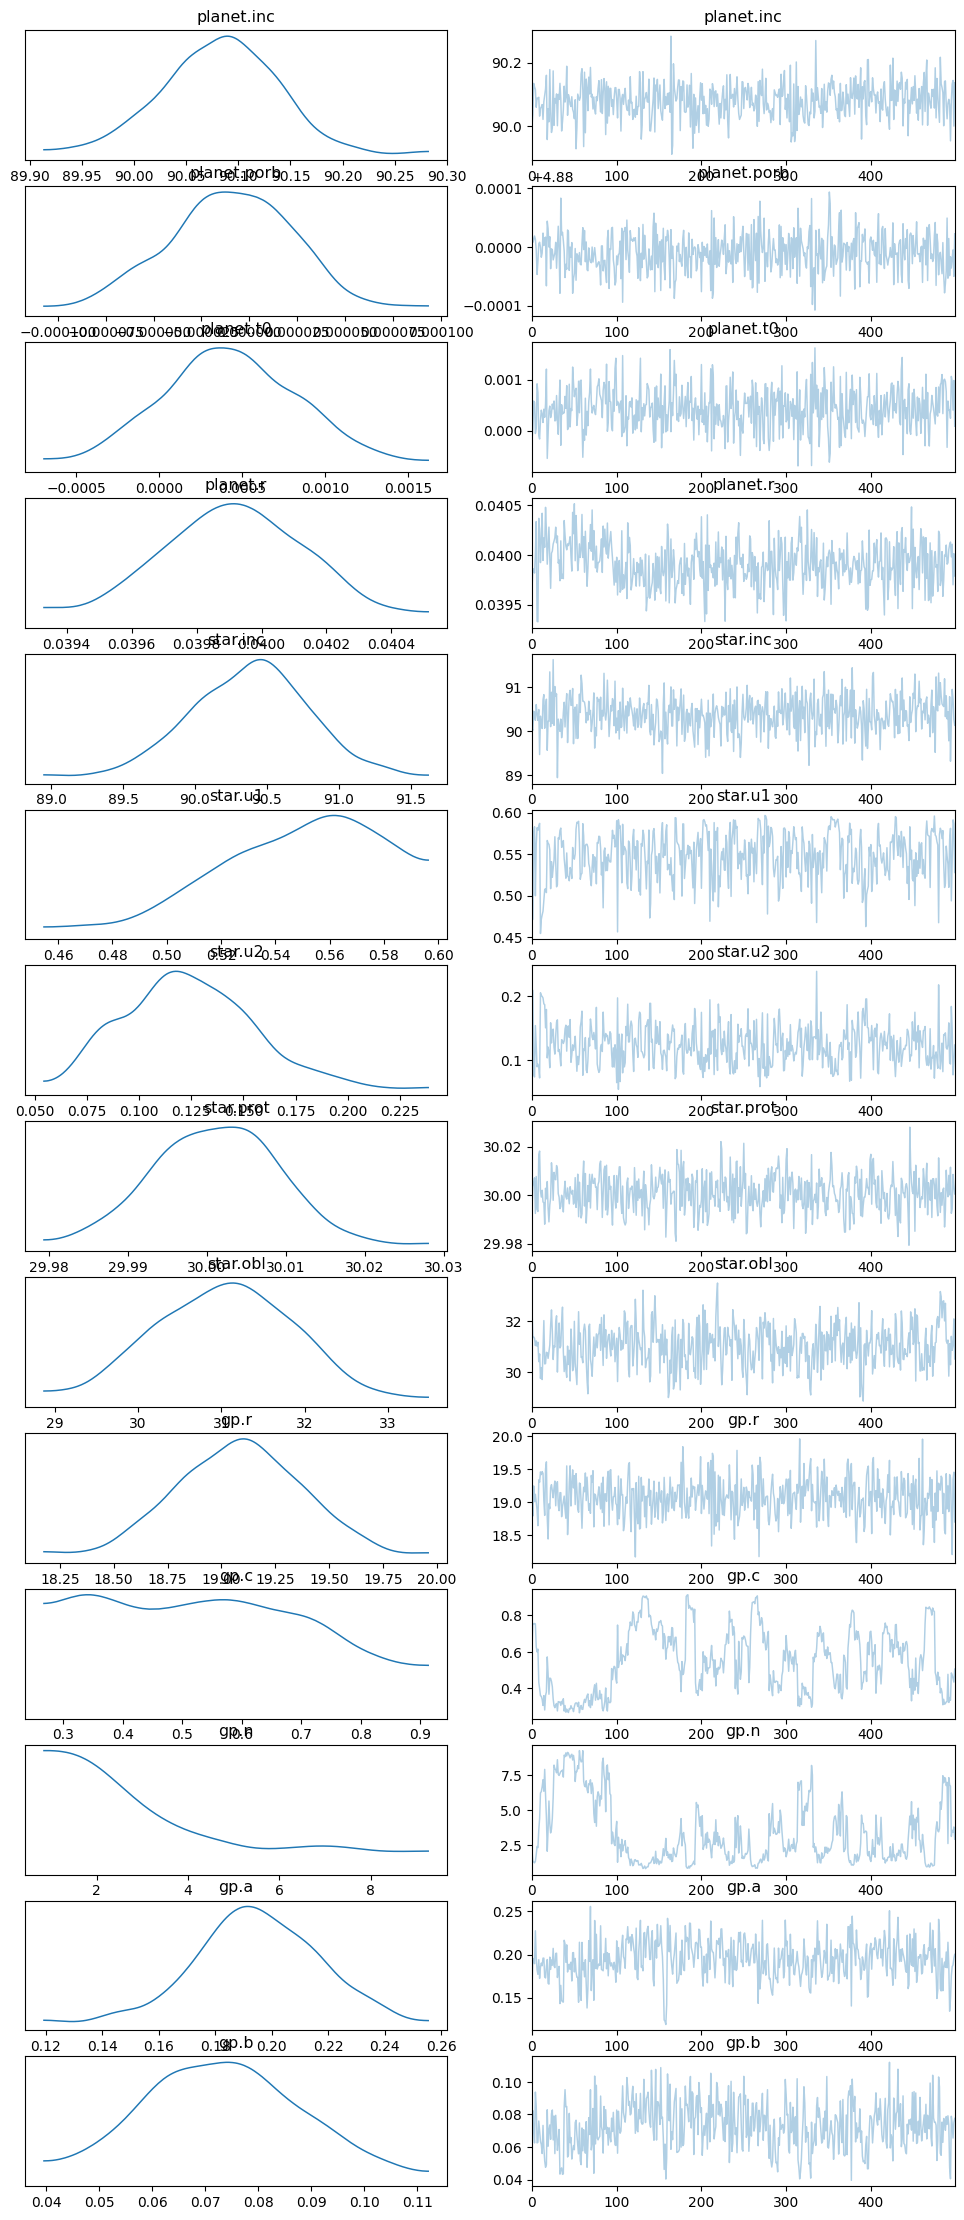

In [33]:
with model:
    az.plot_trace(trace, var_names=free)

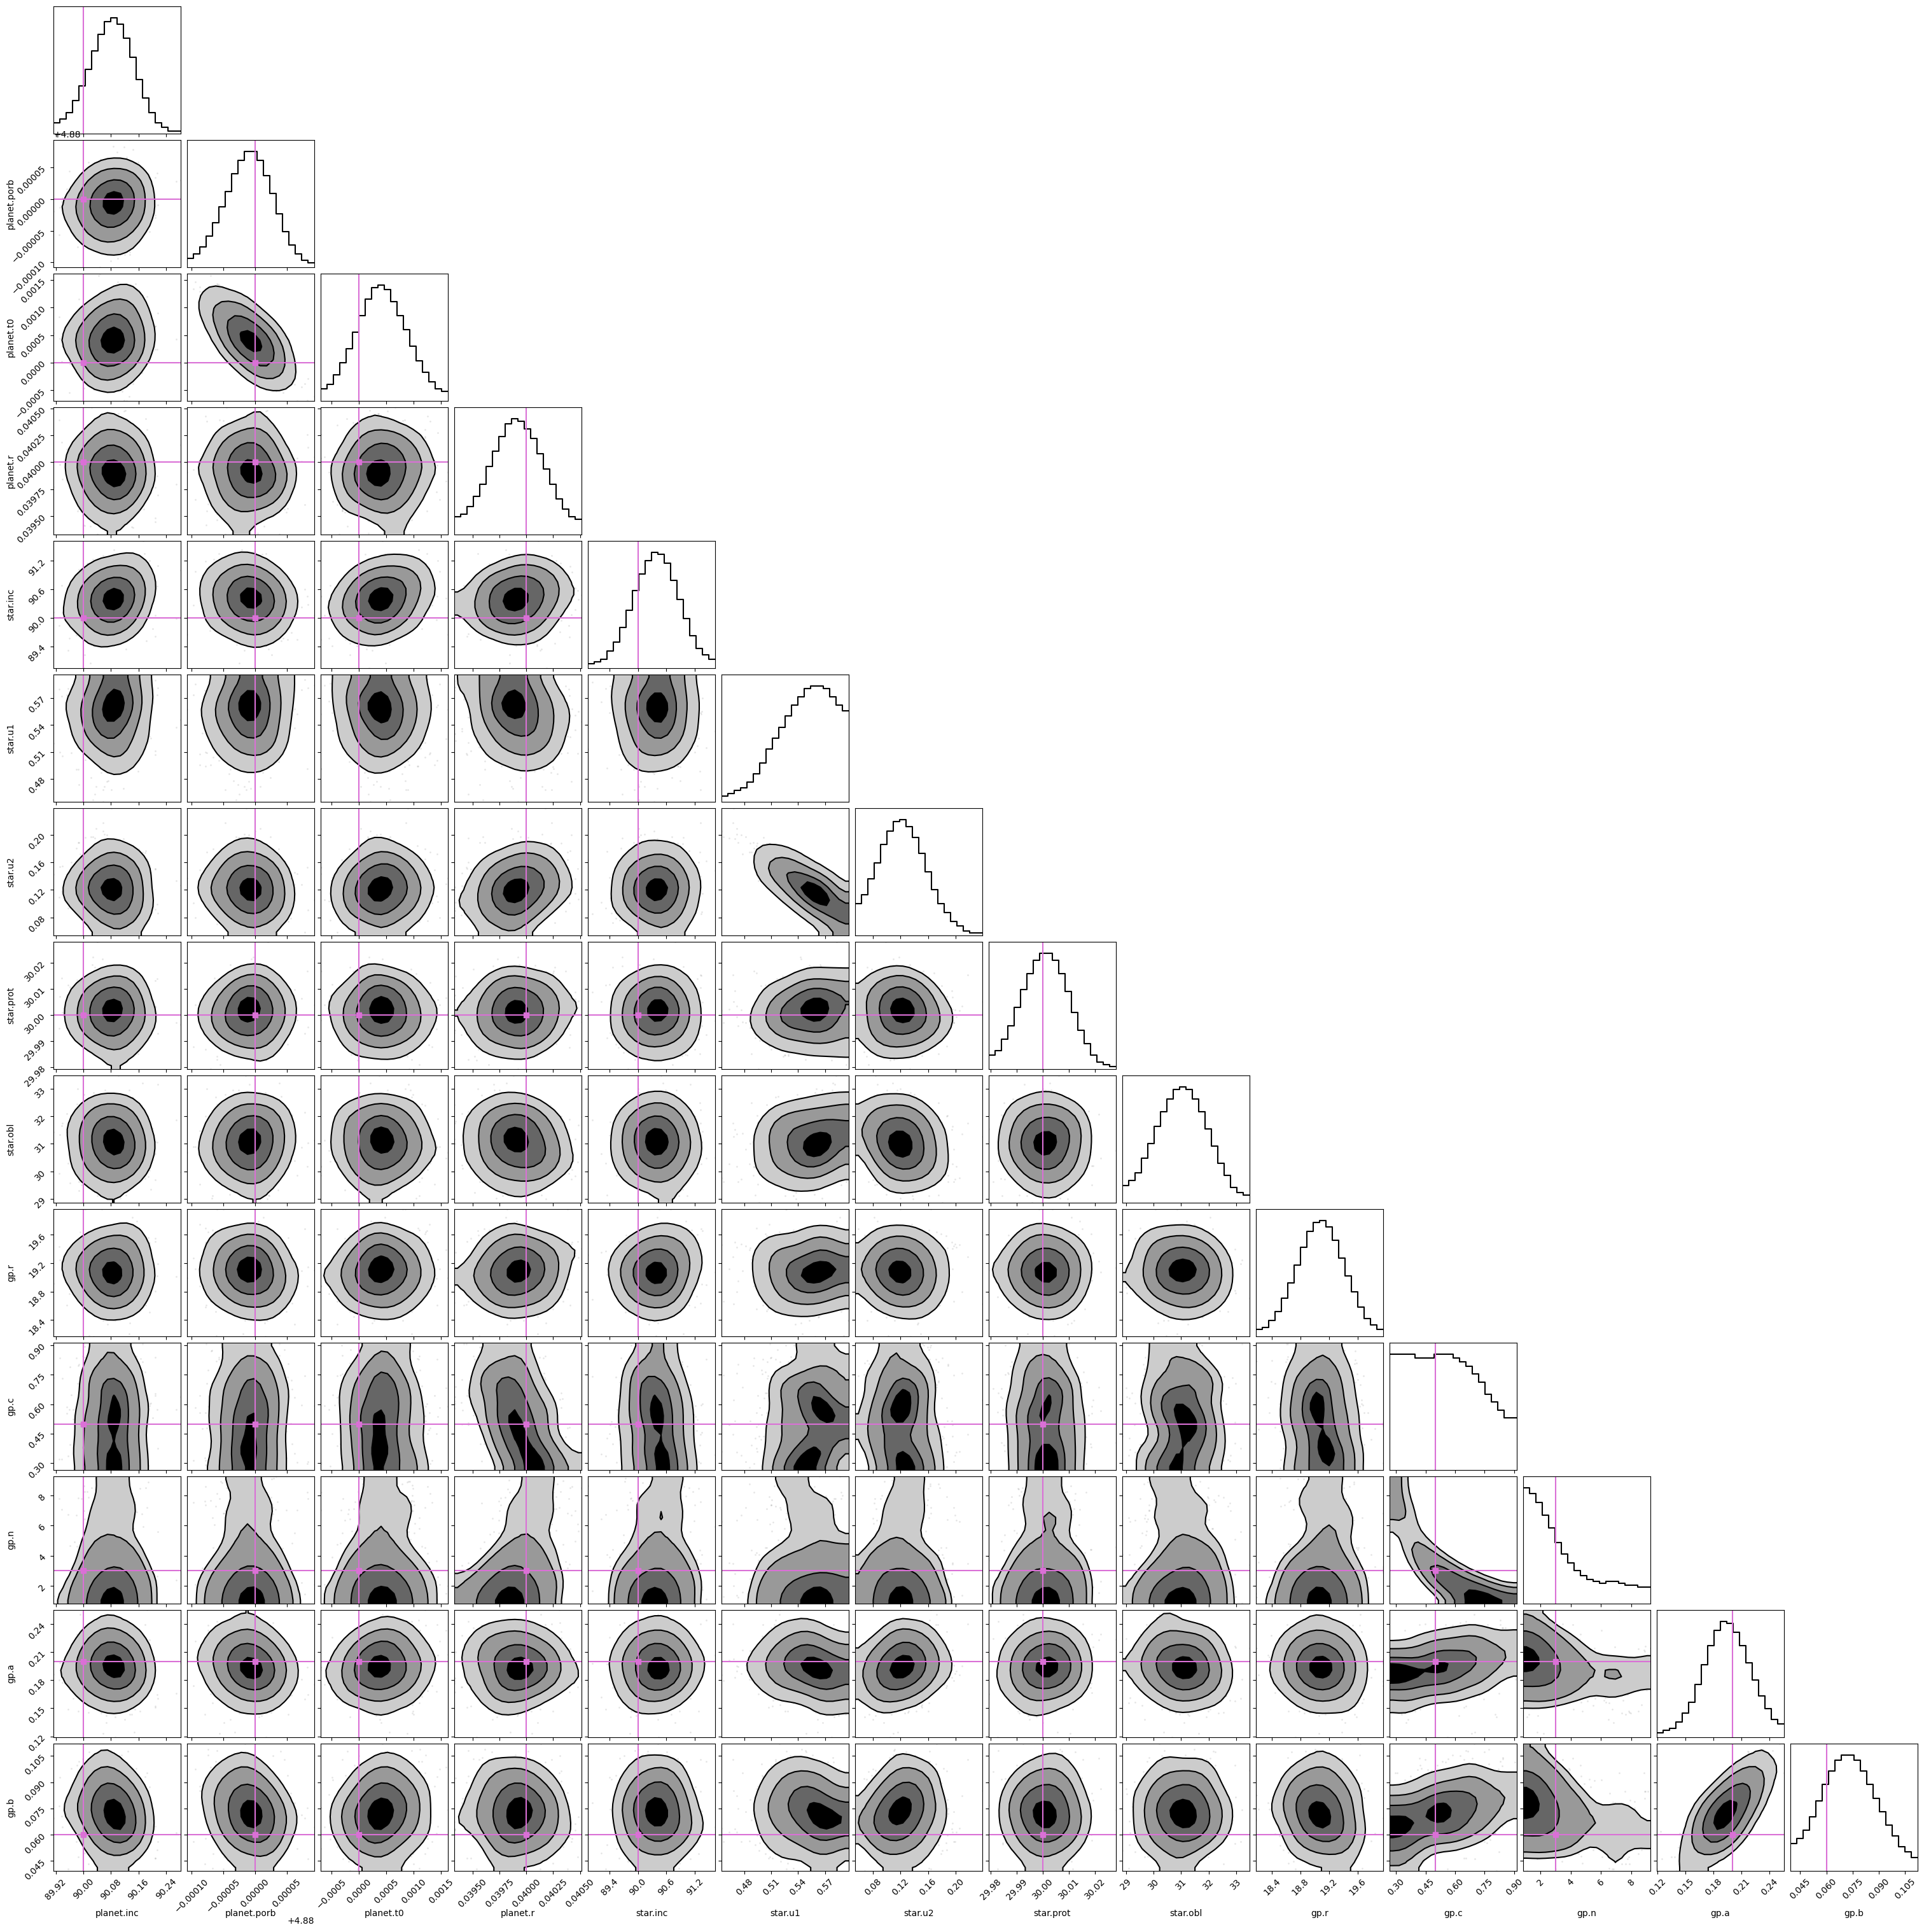

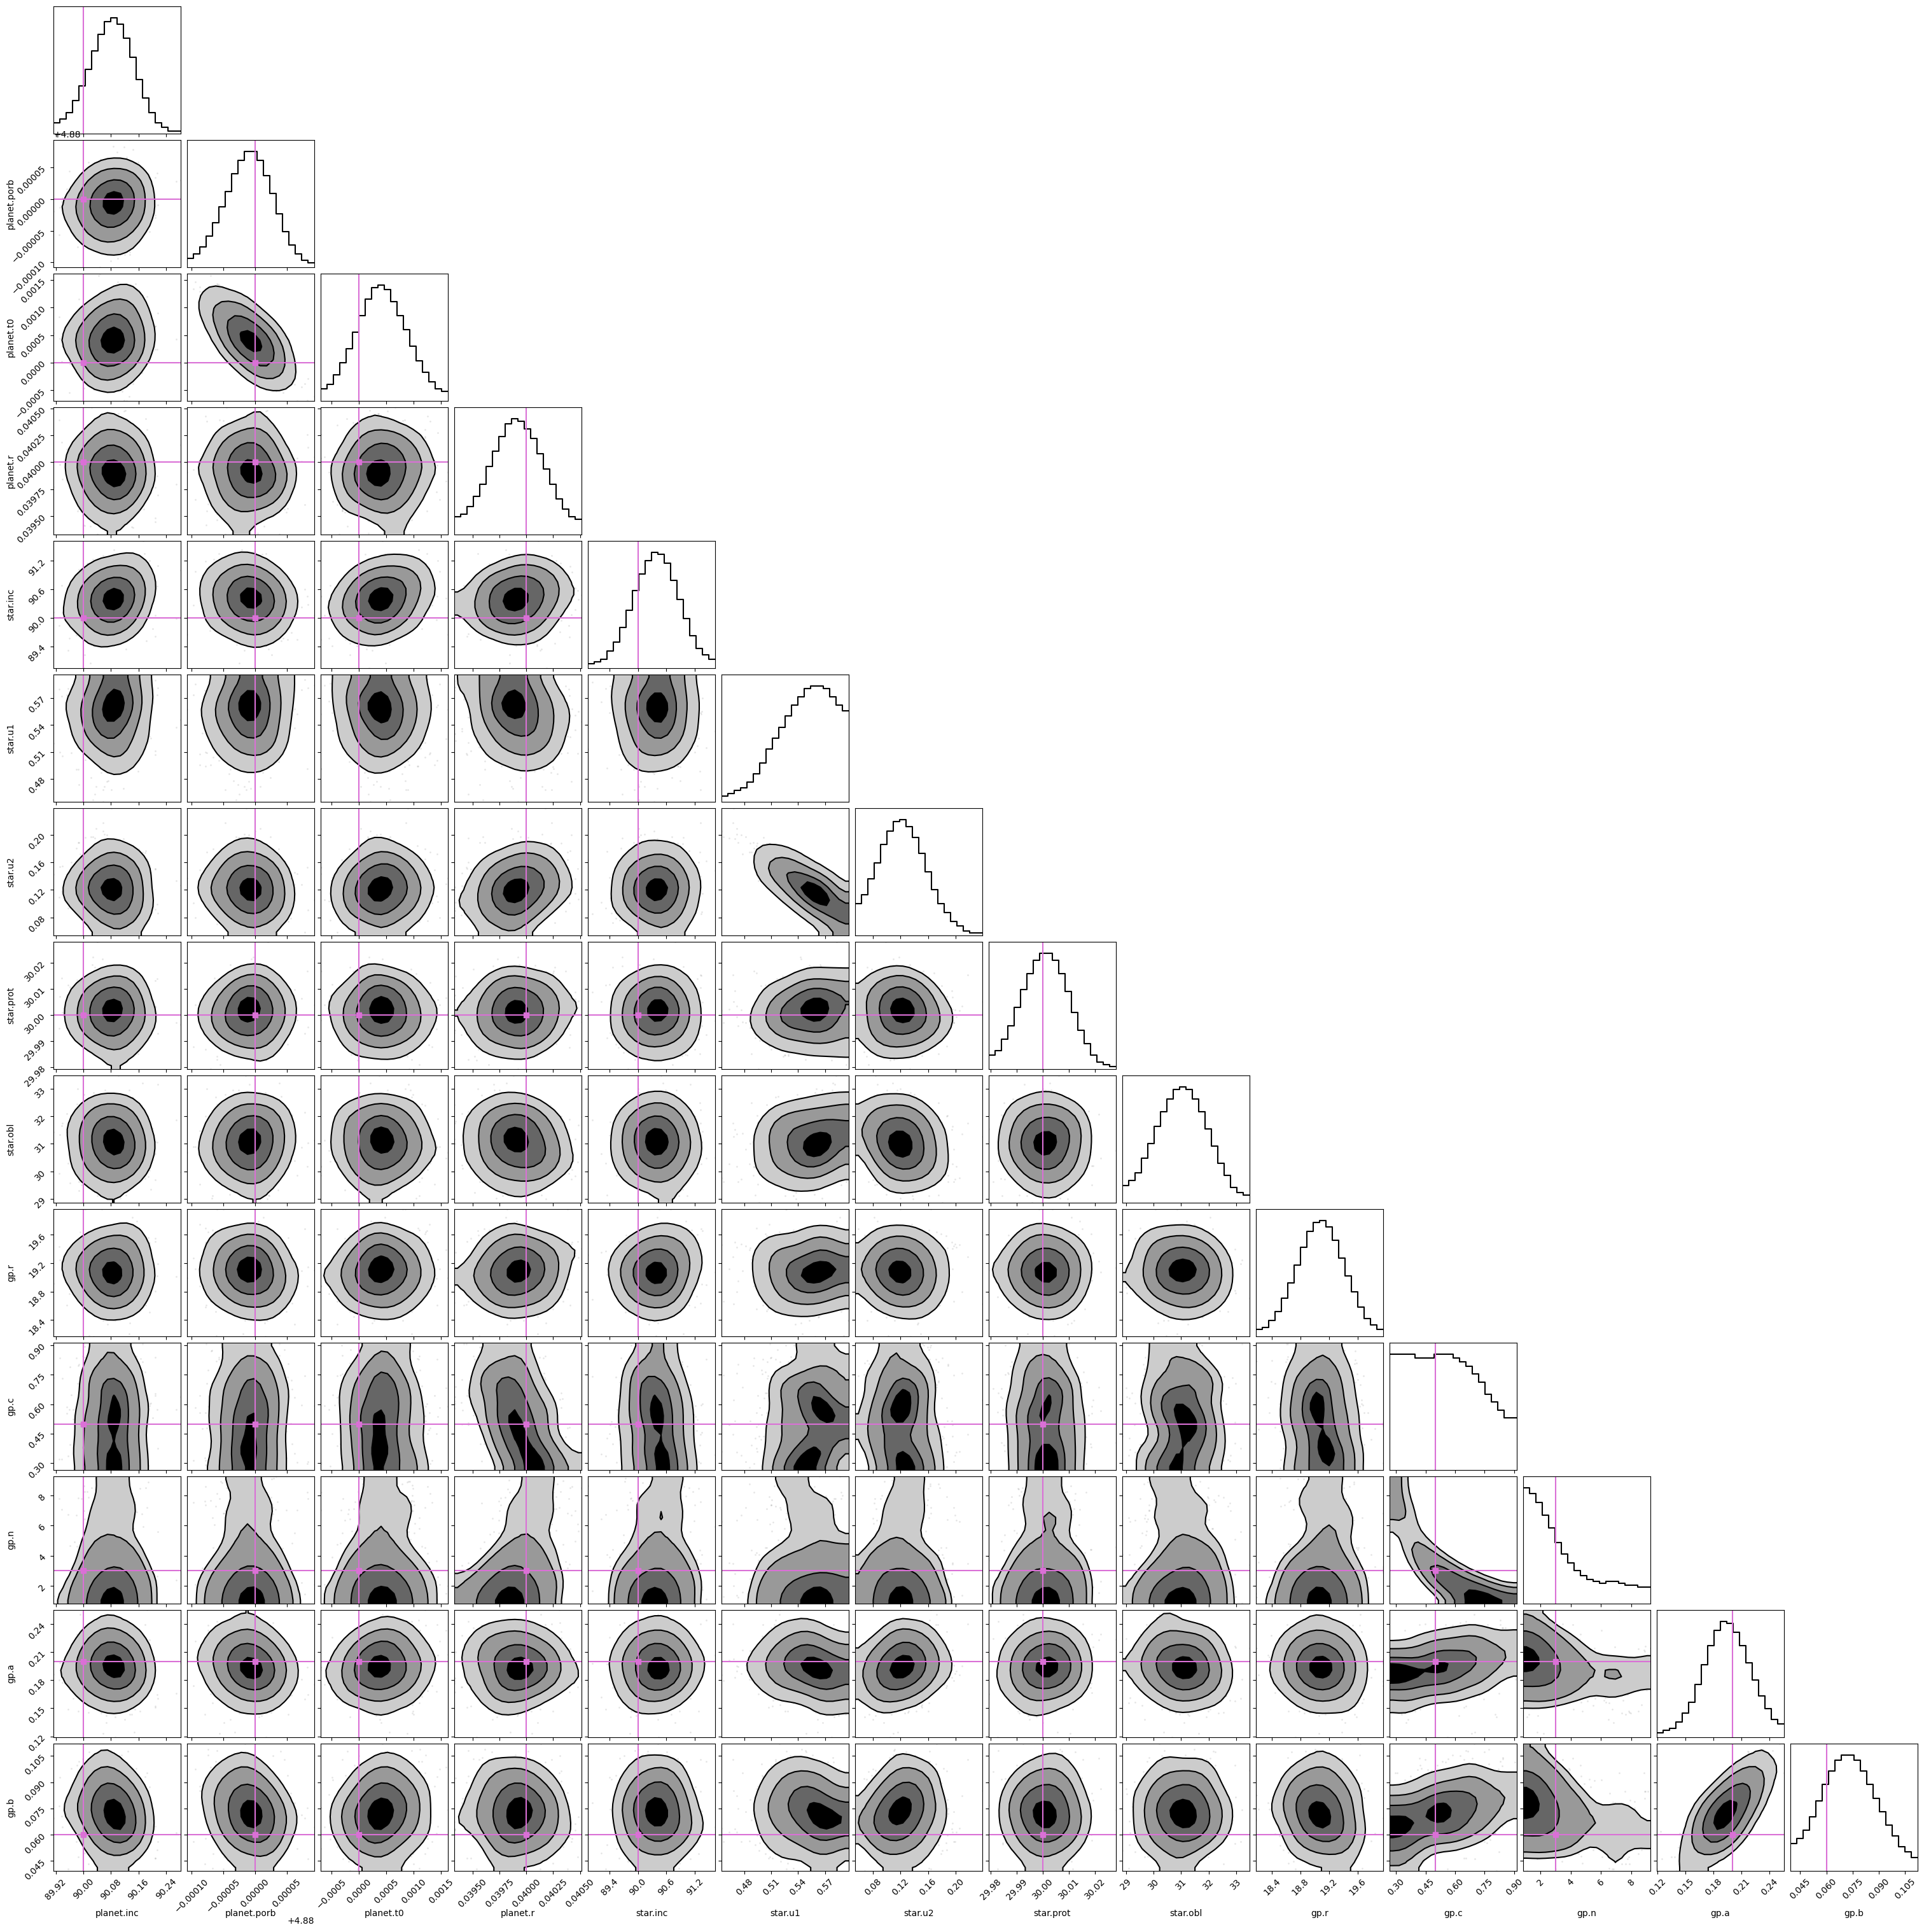

In [34]:
samples = pm.trace_to_dataframe(trace,varnames=free)
corner(np.array(samples), labels=free,
        truths=[params[x]['truth'] for x in free], 
        color='k', 
        truth_color='orchid',
        plot_datapoints=True,
        plot_density=False,
        fill_contours=True,
        smooth=2.,
        smooth1d=2.,
        hist_kwargs=dict(alpha=1))

### let's save our trace

In [35]:
az.to_netcdf(trace,'experiment2-LinearSSP-all.nc')

Got error No model on context stack. trying to find log_likelihood in translation.


'experiment2-LinearSSP-all.nc'

### now, let's work with the samples from the file

In [40]:
samples_fromfile = az.from_netcdf('experiment2-LinearSSP-all.nc')

In [43]:
samples_fromfile.posterior[f'y_model'][0].values.shape

(500, 768)

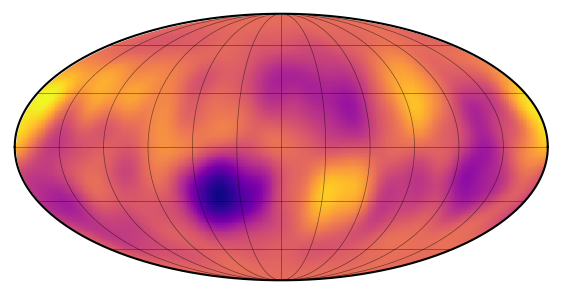

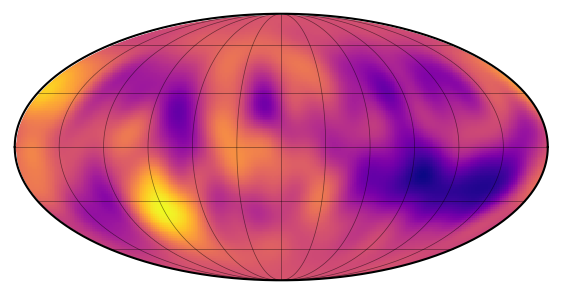

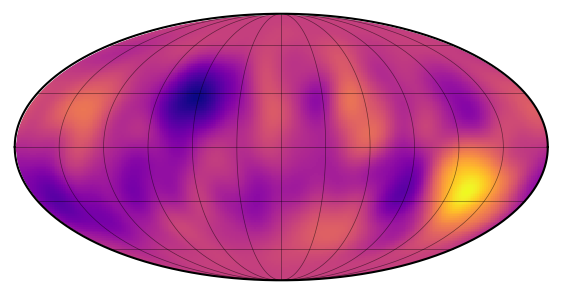

In [45]:
for i in range(num_maps):
    sp.visualize(np.mean(samples_fromfile.posterior[f'y_model'][0].values[:,i*256:(i+1)*256], axis=0))

(1.0, 1.15)

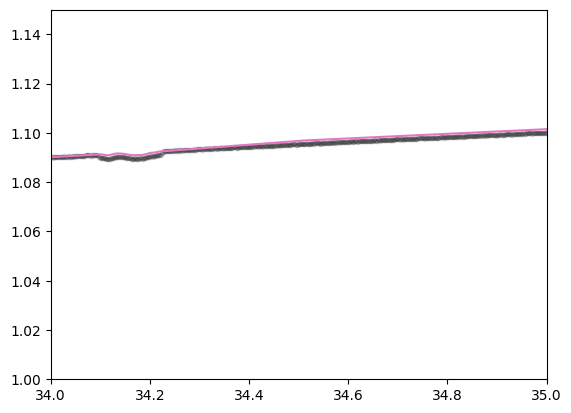

In [50]:
plt.plot(t, flux_obs, "k.", alpha=0.1, label="observed")
plt.plot(t_, np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0), "C6", label="model", alpha=1)
plt.xlim(34,35)
plt.ylim(1,1.15)

In [56]:
import pandas as pd
data_dict = {var: samples_fromfile.posterior[var].values.flatten() for var in free}
samples_df = pd.DataFrame(data_dict, columns=free)

In [52]:
K00 = 0.
K01 = 10.
K10 = np.log(1/2)
K11 = 10.
alpha = np.exp(K00 + (K10 - K00) * params['gp.a']['truth'])
beta = np.exp(K10 + (K11 - K10) * params['gp.b']['truth'])  

sp_mu = alpha / (alpha + beta) * 180 / np.pi 
sp_var = alpha * beta / (np.square(alpha + beta) * (alpha + beta + 1)) * 180 / np.pi

In [53]:
params['sp.mu'] = {'truth': sp_mu, 'dist': None, 'args': None}
params['sp.var'] = {'truth': sp_var, 'dist': None, 'args': None}

replacements = {'gp.a': 'sp.mu', 'gp.b': 'sp.var'}
free = [replacements.get(item, item) for item in free]

Text(0, 0.5, 'probability')

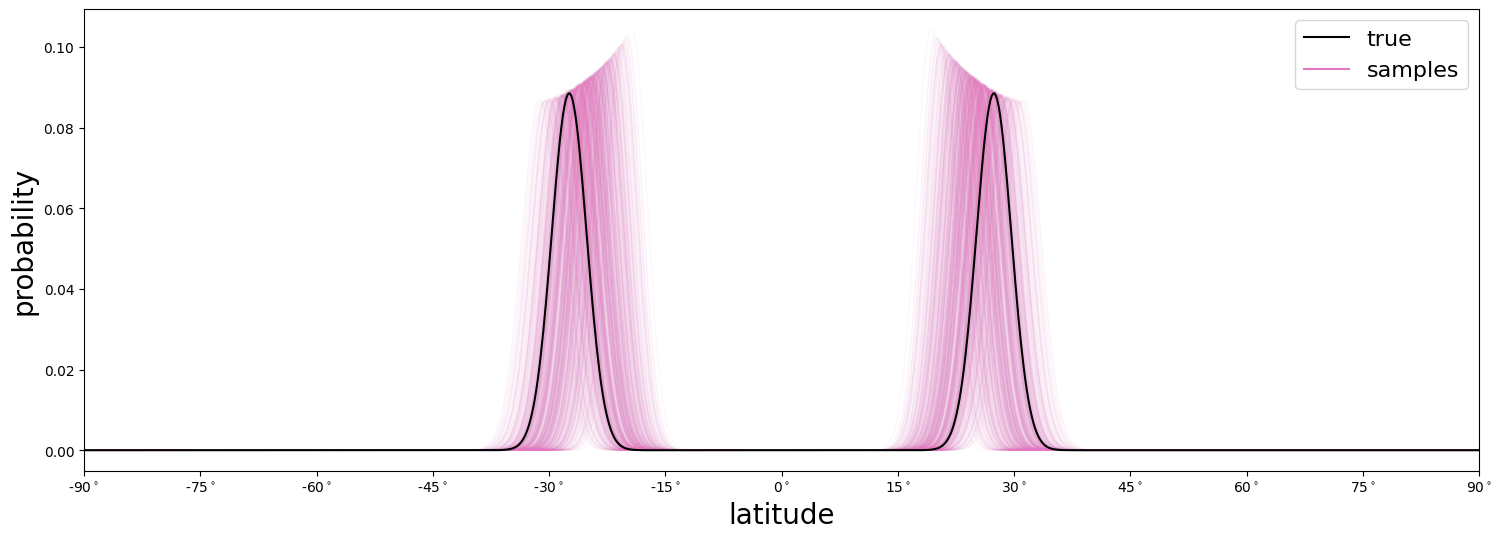

In [55]:
from scipy.stats import norm as Normal

lat=np.linspace(-90., 90., 1000)
nsamples=500
fig, ax = plt.subplots(1)
fig.set_size_inches(18, 6)
pdf = 0.5 * (
        Normal.pdf(lat, params['sp.mu']['truth'], np.sqrt(params['sp.var']['truth']))
        + Normal.pdf(lat, -params['sp.mu']['truth'], np.sqrt(params['sp.var']['truth']))
    )
for k in range(nsamples):
    ax.plot(lat, 0.5*(Normal.pdf(lat, samples_fromfile.posterior['sp.mu'][0][k], np.sqrt(samples_fromfile.posterior['sp.var'][0][k]))+Normal.pdf(lat, -samples_fromfile.posterior['sp.mu'][0][k], np.sqrt(samples_fromfile.posterior['sp.var'][0][k]))),'C6',lw=1, alpha=0.05, zorder=-1)
ax.plot(lat, pdf,'k',label='true')
ax.plot(lat, np.nan * lat, "C6-", label="samples")
ax.legend(loc="upper right", fontsize=16)
ax.set_xlim(-90, 90)
xticks = [-90, -75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75, 90]
ax.set_xticks(xticks)
ax.set_xticklabels(["{:d}$^\circ$".format(xt) for xt in xticks])
ax.set_xlabel("latitude", fontsize=20)
ax.set_ylabel("probability", fontsize=20)
# plt.savefig("figures/experiment-1-active-lats.pdf", bbox_inches="tight", dpi=300)

In [57]:
samples_df.columns

Index(['planet.inc', 'planet.porb', 'planet.t0', 'planet.r', 'star.inc',
       'star.u1', 'star.u2', 'star.prot', 'star.obl', 'gp.r', 'gp.c', 'gp.n',
       'sp.mu', 'sp.var'],
      dtype='object')

In [58]:
samples_df['star.inc'] = 180-samples_df['star.inc']

In [59]:
samples_df['star.obl'] = -samples_df['star.obl']

In [60]:
custom_labels = {
    'planet.inc': r'$i_p$',
    'planet.ecc': r'$e$',
    'planet.porb': r'$P$',
    'planet.t0': r'$t_0$',
    'planet.r': r'$R_p/R_\star$',
    'star.inc': r'$i_\star$',
    'star.u1': r'$u_1$',
    'star.u2': r'$u_2$',
    'star.prot': r'$P_\star$',
    'star.obl': r'$\lambda_\star$',
    'sp.mu': r'$\mu_\phi$',
    'sp.var': r'$\sigma^2_\phi$',
    'gp.r': r'$\mathbb{r}$',
    'gp.c': r'$\mathbb{c}$',
    'gp.n': r'$\mathbb{n}$'
}

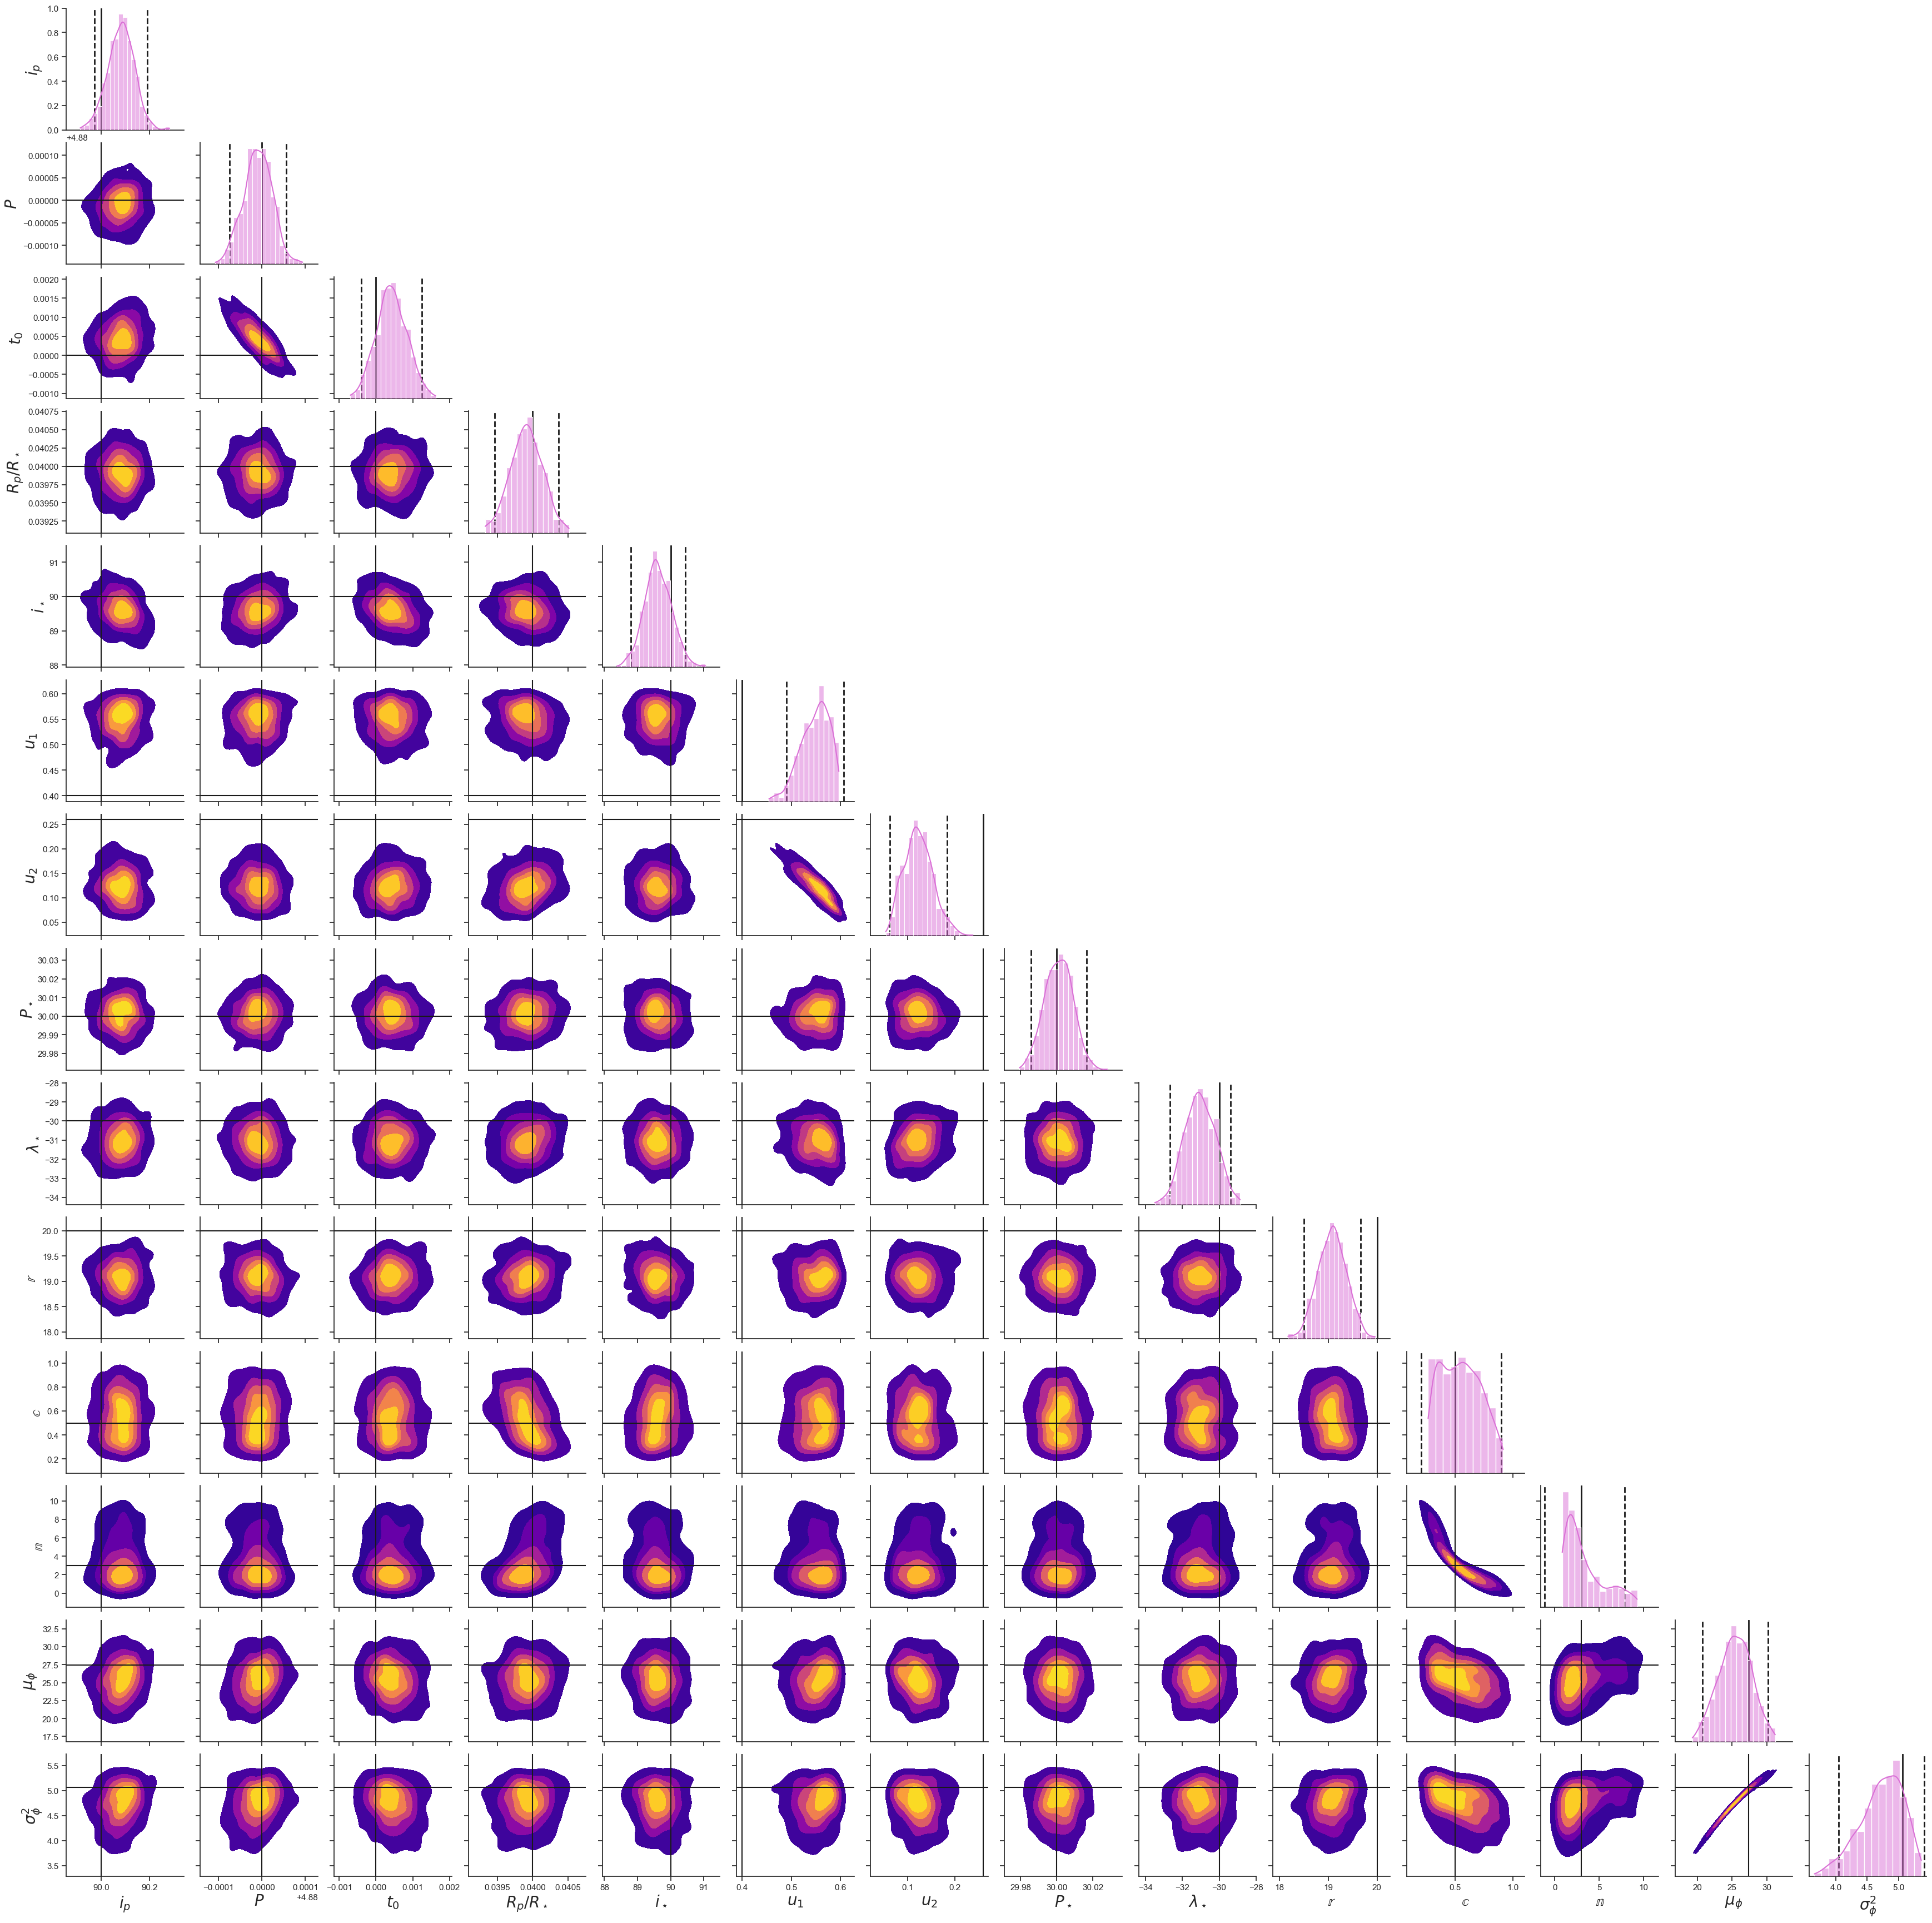

In [61]:
import pandas as pd
import seaborn as sns
sns.set(style='ticks')

# Create the pair grid
g = sns.PairGrid(samples_df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the lower triangle
g.map_lower(sns.kdeplot, cmap='plasma', levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g.map_upper(remove_upper)

for i, var in enumerate(free):
    truth = params[var]['truth']
    # if var == 'star.inc':
    #     truth = 180 - params[var]['truth']
    # if var == 'star.obl':
    #     truth = - params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=2)
    # g.axes[i, i].axhline(truth, color='k', linestyle='-')

    std = np.std(samples_df[var])
    mean = np.mean(samples_df[var])
    sigma_plus = mean + 2 * std
    sigma_minus = mean - 2 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(free):
    for j, x_var in enumerate(free):
        if j < i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']

            # if y_var == 'star.inc':
            #     truth_y = 180 - params[y_var]['truth']
            # if y_var == 'star.obl':
            #     truth_y = - params[y_var]['truth']

            # if x_var == 'star.inc':
            #     truth_x = 180 - params[x_var]['truth']
            # if x_var == 'star.obl':
            #     truth_x = - params[x_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

for i, var in enumerate(free):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

# plt.savefig("figures/experiment-1-corner-all.pdf", bbox_inches="tight", dpi=300)

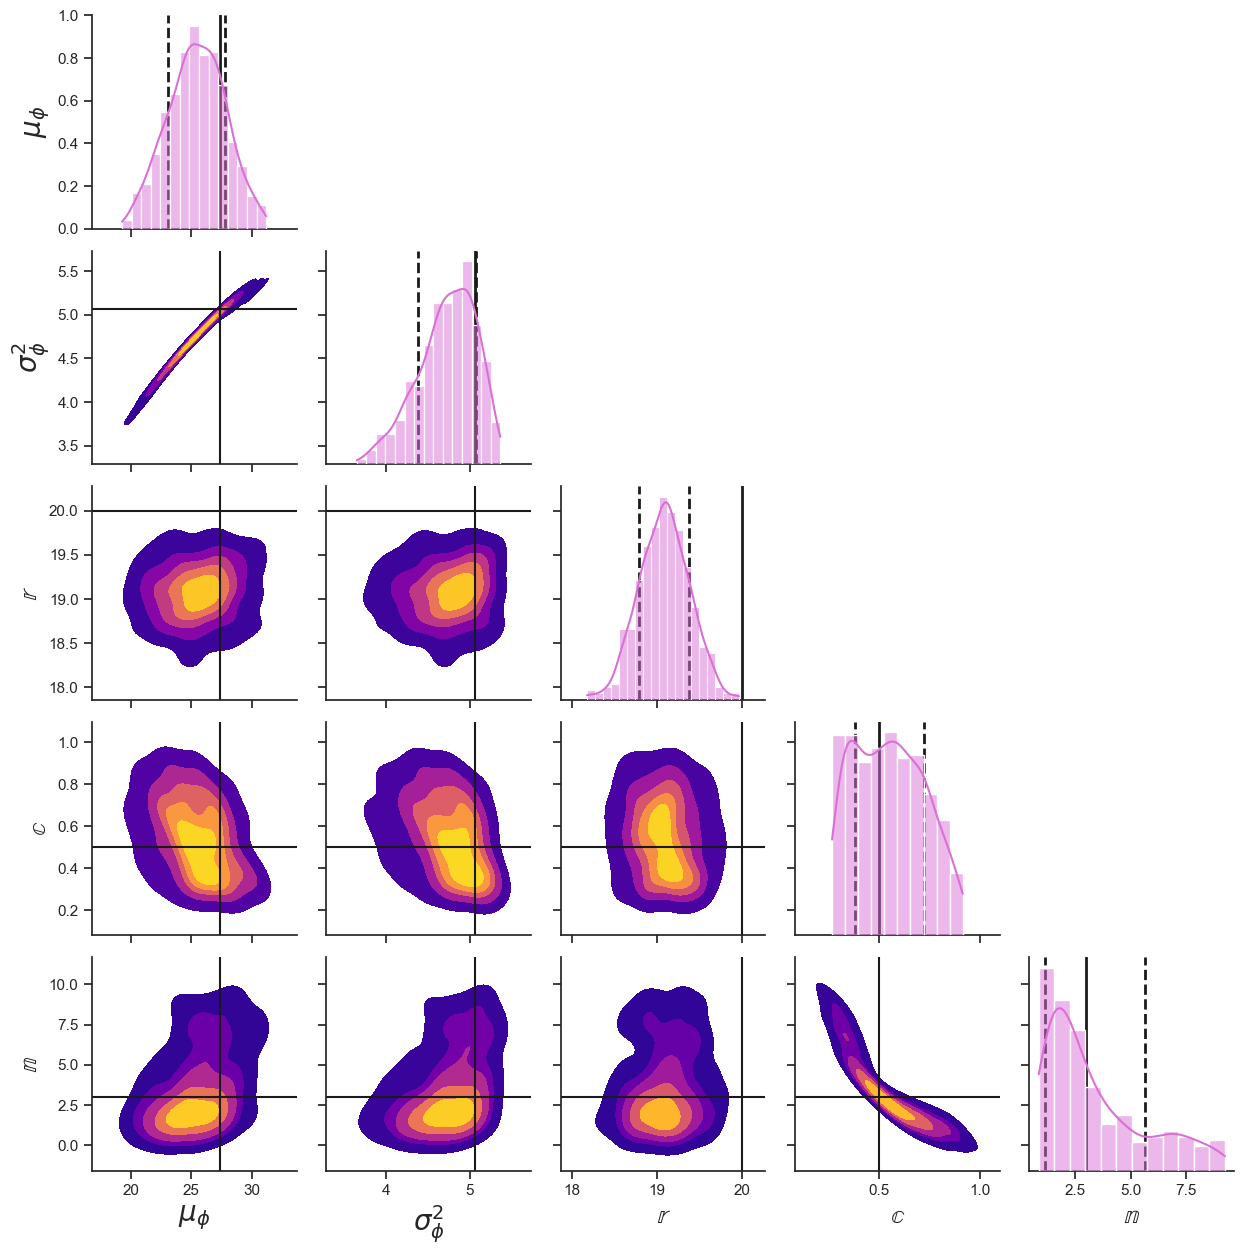

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style='ticks')

# Filter the dataframe to include only the desired columns
desired_columns = ['sp.mu', 'sp.var', 'gp.r', 'gp.c', 'gp.n']
filtered_df = samples_df[desired_columns]

# Create the pair grid
g = sns.PairGrid(filtered_df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the lower triangle
g.map_lower(sns.kdeplot, cmap='plasma', levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g.map_upper(remove_upper)

for i, var in enumerate(desired_columns):
    truth = params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=2)

    std = np.std(filtered_df[var])
    mean = np.mean(filtered_df[var])
    sigma_plus = mean + 1 * std
    sigma_minus = mean - 1 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(desired_columns):
    for j, x_var in enumerate(desired_columns):
        if j < i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

for i, var in enumerate(desired_columns):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

# plt.savefig("figures/experiment-1-corner-gps.pdf", bbox_inches="tight", dpi=300)

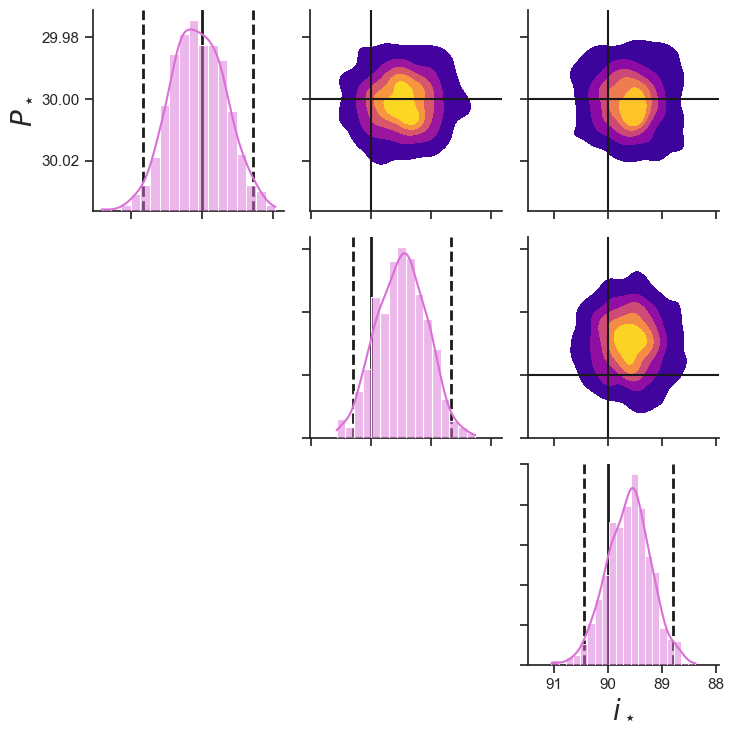

In [63]:
sns.set(style='ticks')

# Filter the dataframe for the desired columns
columns = ['star.prot', 'star.obl', 'star.inc']
df = samples_df[columns]

# Create the pair grid
g = sns.PairGrid(df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the upper triangle
g.map_upper(sns.kdeplot, cmap='plasma', levels=6, fill=True)

# Custom function to remove lower triangle
def remove_lower(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the lower triangle
g.map_lower(remove_lower)

# Add truth lines and labels
for i, var in enumerate(columns):
    truth = params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=2)

    std = np.std(df[var])
    mean = np.mean(df[var])
    sigma_plus = mean + 2 * std
    sigma_minus = mean - 2 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(columns):
    for j, x_var in enumerate(columns):
        if j > i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

# Add labels
for i, var in enumerate(columns):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

# Invert axes to display the plot upside down
for ax in g.axes.flat:
    ax.invert_yaxis()
    ax.invert_xaxis()

# Add missing ticks and labels
# for i in range(3):
#     for j in range(3):
#         ax = g.axes[i, j]
        
#         # Set x-axis ticks and labels
#         if i == 2:  # bottom row
#             ax.set_xticks([100, 90, 80])
#             ax.set_xticklabels([100, 90, 80])
        
#         # Set y-axis ticks and labels
#         if j == 0:  # leftmost column
#             if i == 0:  # top-left plot
#                 ax.set_yticks([-0.0005, 0, 0.0005])
#                 ax.set_yticklabels([-0.0005, 0, 0.0005])
#             else:
#                 ax.set_yticks([100, 90, 80])
#                 ax.set_yticklabels([100, 90, 80])

# Adjust the layout
plt.tight_layout()

# Save the figure
# plt.savefig("figures/experiment-1-corner-star-params-inverted-with-ticks.pdf", bbox_inches="tight", dpi=300)

In [64]:
import numpy as np

for i, var in enumerate(free):
    truth = params[var]['truth']
    if var == 'star.inc':
        truth = 180 - params[var]['truth']
    if var == 'star.obl':
        truth = -params[var]['truth']

    samples = samples_df[var]

    median = np.median(samples)
    std = np.std(samples)
    mean = np.mean(samples)

    lower_bound = np.percentile(samples, 16)
    upper_bound = np.percentile(samples, 84)
    
    print(f'{var}: median = {median}, mean = {mean}, std = {std}, 68% credible interval = [{median - lower_bound}, {upper_bound - median}]')


planet.inc: median = 90.08496544667088, mean = 90.08152820439636, std = 0.05488691763251176, 68% credible interval = [0.05810721115004469, 0.04986423181841815]
planet.porb: median = 4.87999047732284, mean = 4.879990415113489, std = 3.281874118829678e-05, 68% credible interval = [3.170707372213144e-05, 3.265163599674992e-05]
planet.t0: median = 0.00042068588183845346, mean = 0.0004276806385225372, std = 0.00041302127189961807, 68% credible interval = [0.00040756773576045957, 0.0004405154472873631]
planet.r: median = 0.039918283221783826, mean = 0.03991427767753275, std = 0.00022542458742505676, 68% credible interval = [0.0002313842708122557, 0.00022926831970588452]
star.inc: median = 89.58971078693, mean = 89.61927592024419, std = 0.41067021581676083, 68% credible interval = [0.36294404182176265, 0.43050966928367984]
star.u1: median = 0.5518523006196071, mean = 0.5482773228964227, std = 0.028981489536017223, 68% credible interval = [0.03374994776171236, 0.02678983277086555]
star.u2: med

In [65]:
map_samples = samples_fromfile.posterior[f'y_model'][0].values

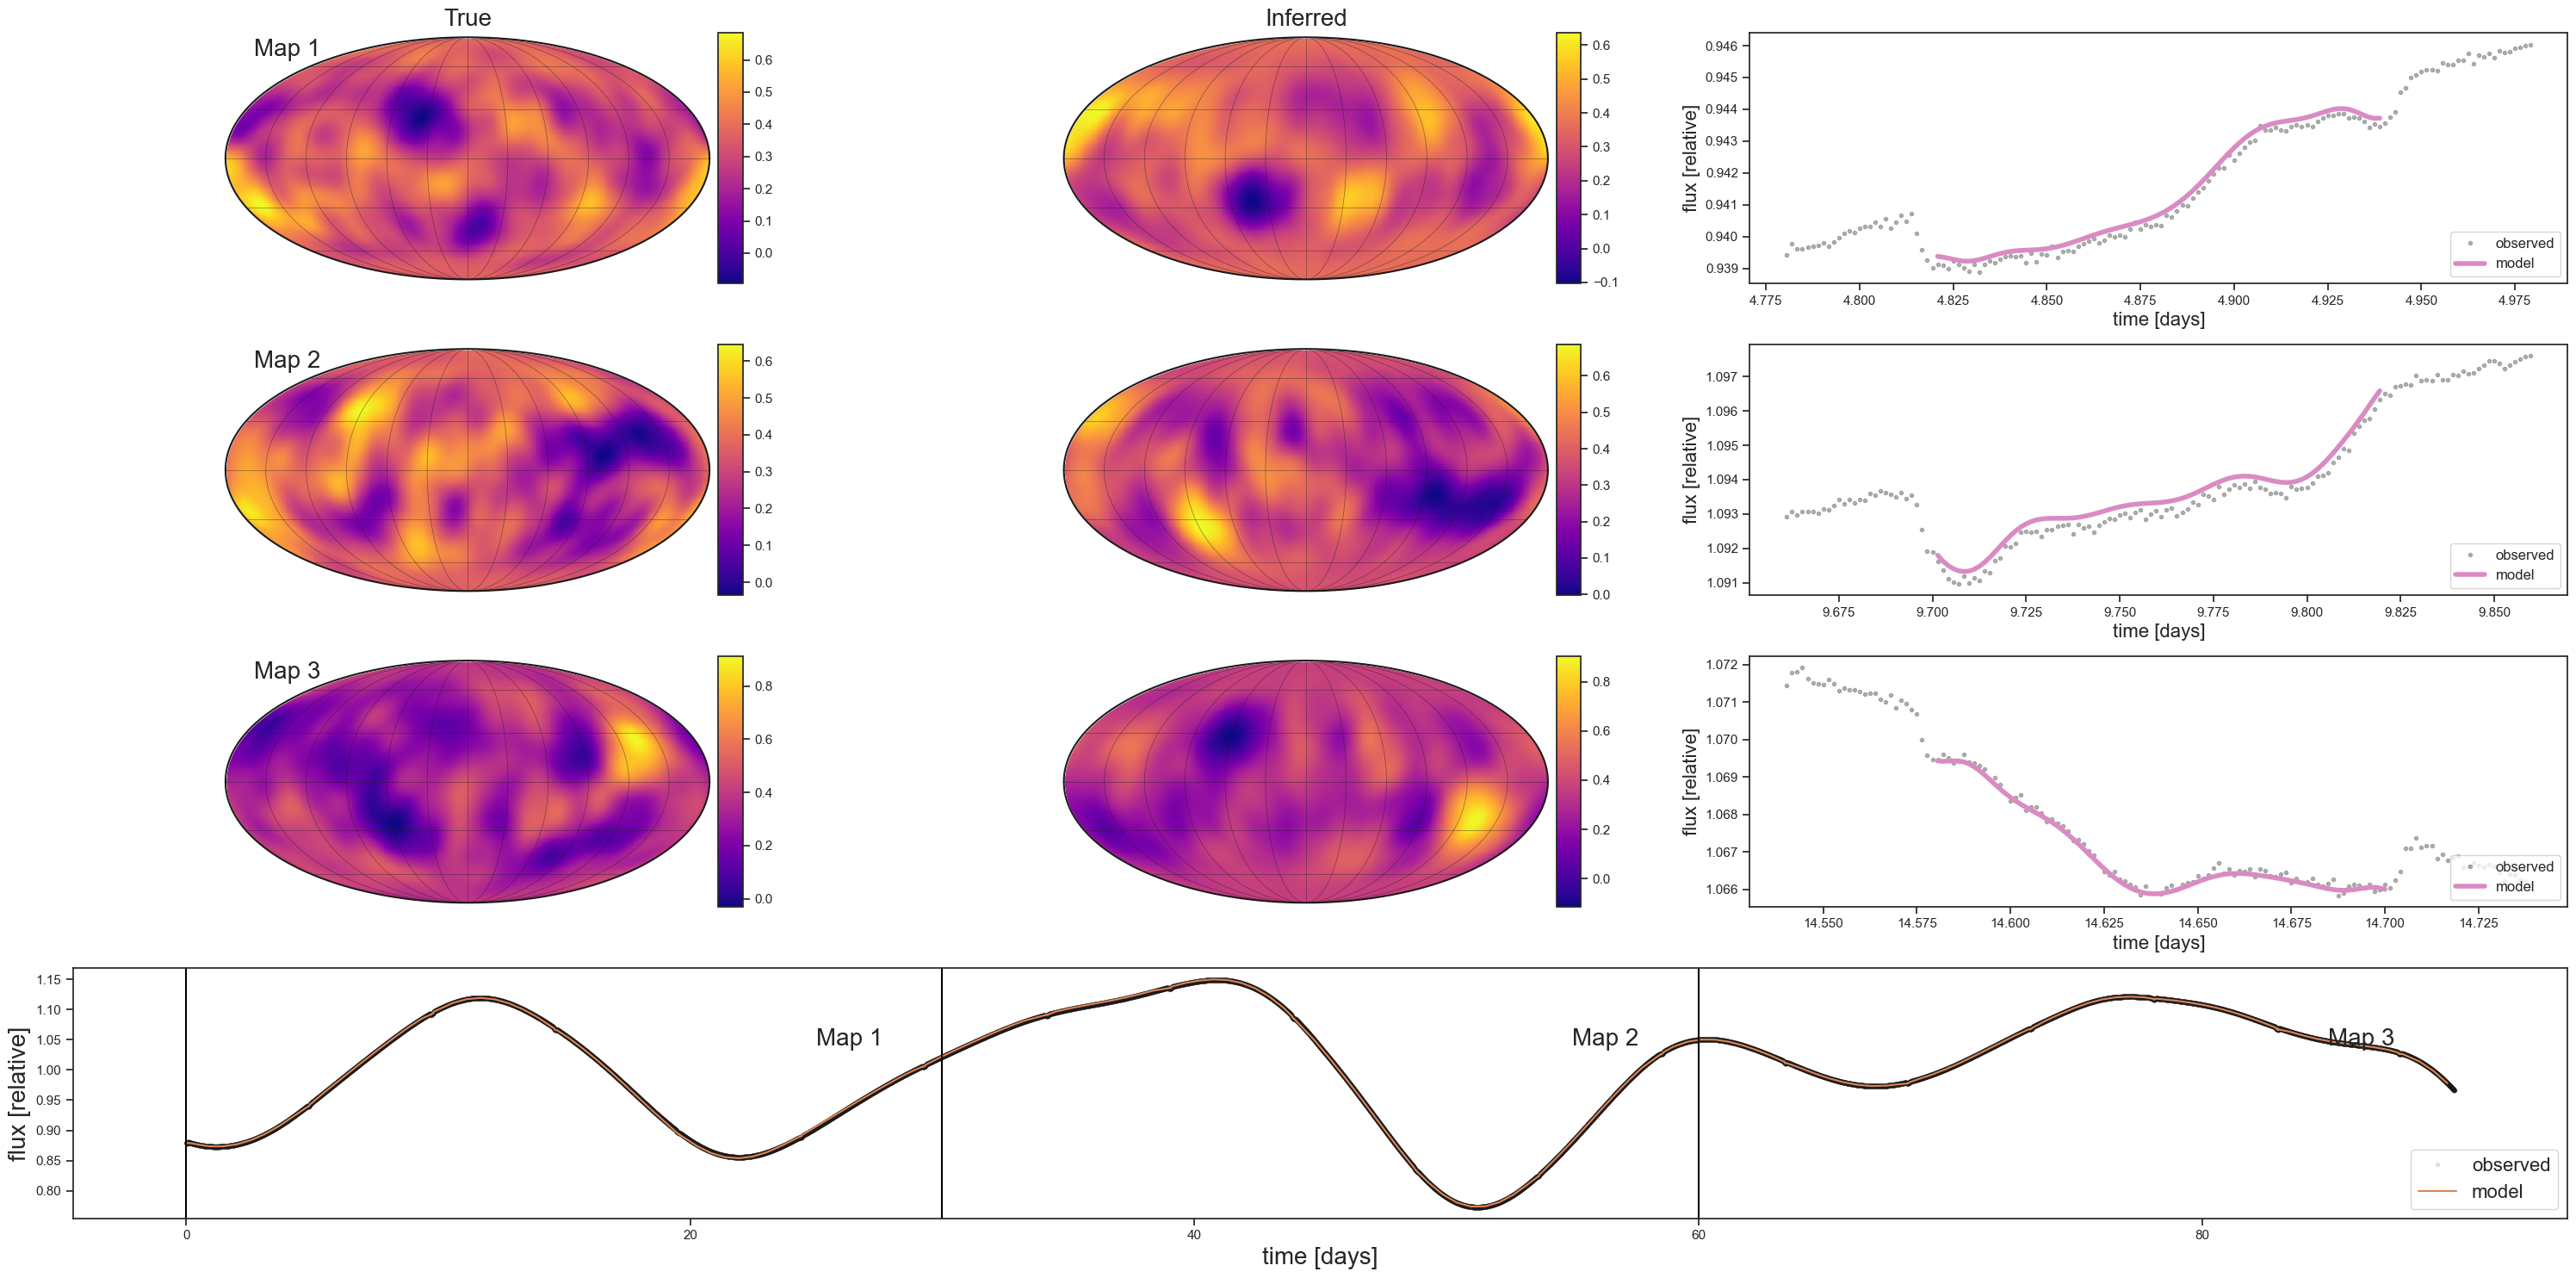

In [88]:
num_maps = 3

cmap = plt.get_cmap("plasma")
cmap.set_under("#666666")
cmap.set_over("w")
cnorm = lambda: Normalize(vmin=0.0)
fig = plt.figure(figsize=(30, 15))  # Increased figure size
fig.subplots_adjust(wspace=0.15, hspace=0.3)  # Added hspace adjustment

# Create a 4x3 grid (3 rows for maps, 1 row for flux, 3 columns)
ax = [plt.subplot2grid((num_maps+1, 3), (i, j), colspan=1, rowspan=1) 
      for i in range(num_maps) for j in range(3)]
ax.append(plt.subplot2grid((num_maps+1, 3), (num_maps, 0), colspan=3, rowspan=1))

# Show the true and inferred maps
for i in range(num_maps):
    # Show the true map
    map_true = starry.Map(15, udeg=2, inc=90, obl=-30)
    map_true[:, :] = ys_true[i]
    map_true.show(ax=ax[3 * i], projection="moll", colorbar=True)
    ax[3*i].annotate(f"Map {i+1}", xy=(-2.5,1.2), fontsize=20)

    # Show the inferred map
    map_inf = starry.Map(ydeg=15, udeg=2)
    map_inf[:, :] = np.mean(map_samples[:,i*256:(i+1)*256], axis=(0))
    map_inf.show(ax=ax[3 * i + 1], projection="moll", colorbar=True)

    # Plot the flux for specific time ranges
    idx = (t > planet.t0.eval()+(i+1)*planet.porb.eval()-0.1) & (t < planet.t0.eval()+(i+1)*planet.porb.eval()+0.1)
    ax[3*i + 2].plot(t[idx], flux_obs[idx], "k.", alpha=0.3, label="observed")
    idx = (t_ > planet.t0.eval()+(i+1)*planet.porb.eval()-0.1) & (t_ < planet.t0.eval()+(i+1)*planet.porb.eval()+0.1)
    ax[3*i + 2].plot(t_[idx], np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0)[idx], "C6", label="model", alpha=1, lw=4)
    ax[3*i + 2].legend(fontsize=12, loc="lower right")
    ax[3*i + 2].set_xlabel("time [days]", fontsize=16)
    ax[3*i + 2].set_ylabel("flux [relative]", fontsize=16)

ax[0].set_title('True', fontsize=20)
ax[1].set_title('Inferred', fontsize=20)
# ax[2].set_title('Flux')

# Show the overall flux model
nt = len(t)
interval = nt // num_maps
ax[-1].plot(t, flux_obs, "k.", alpha=0.1, label="observed")
ax[-1].plot(t_, np.mean(samples_fromfile.posterior[f'flux_model'][0].values, axis=0), label=f"model", color='C1')
for i in range(num_maps):
    ax[-1].axvline(t[i * interval], color='black')
    ax[-1].annotate(f"Map {i+1}", xy=(t[i * interval]+25, 1.04), fontsize=20)
ax[-1].legend(fontsize=16, loc="lower right")
ax[-1].set_xlabel("time [days]", fontsize=20)
ax[-1].set_ylabel("flux [relative]", fontsize=20)

plt.tight_layout()
plt.show()

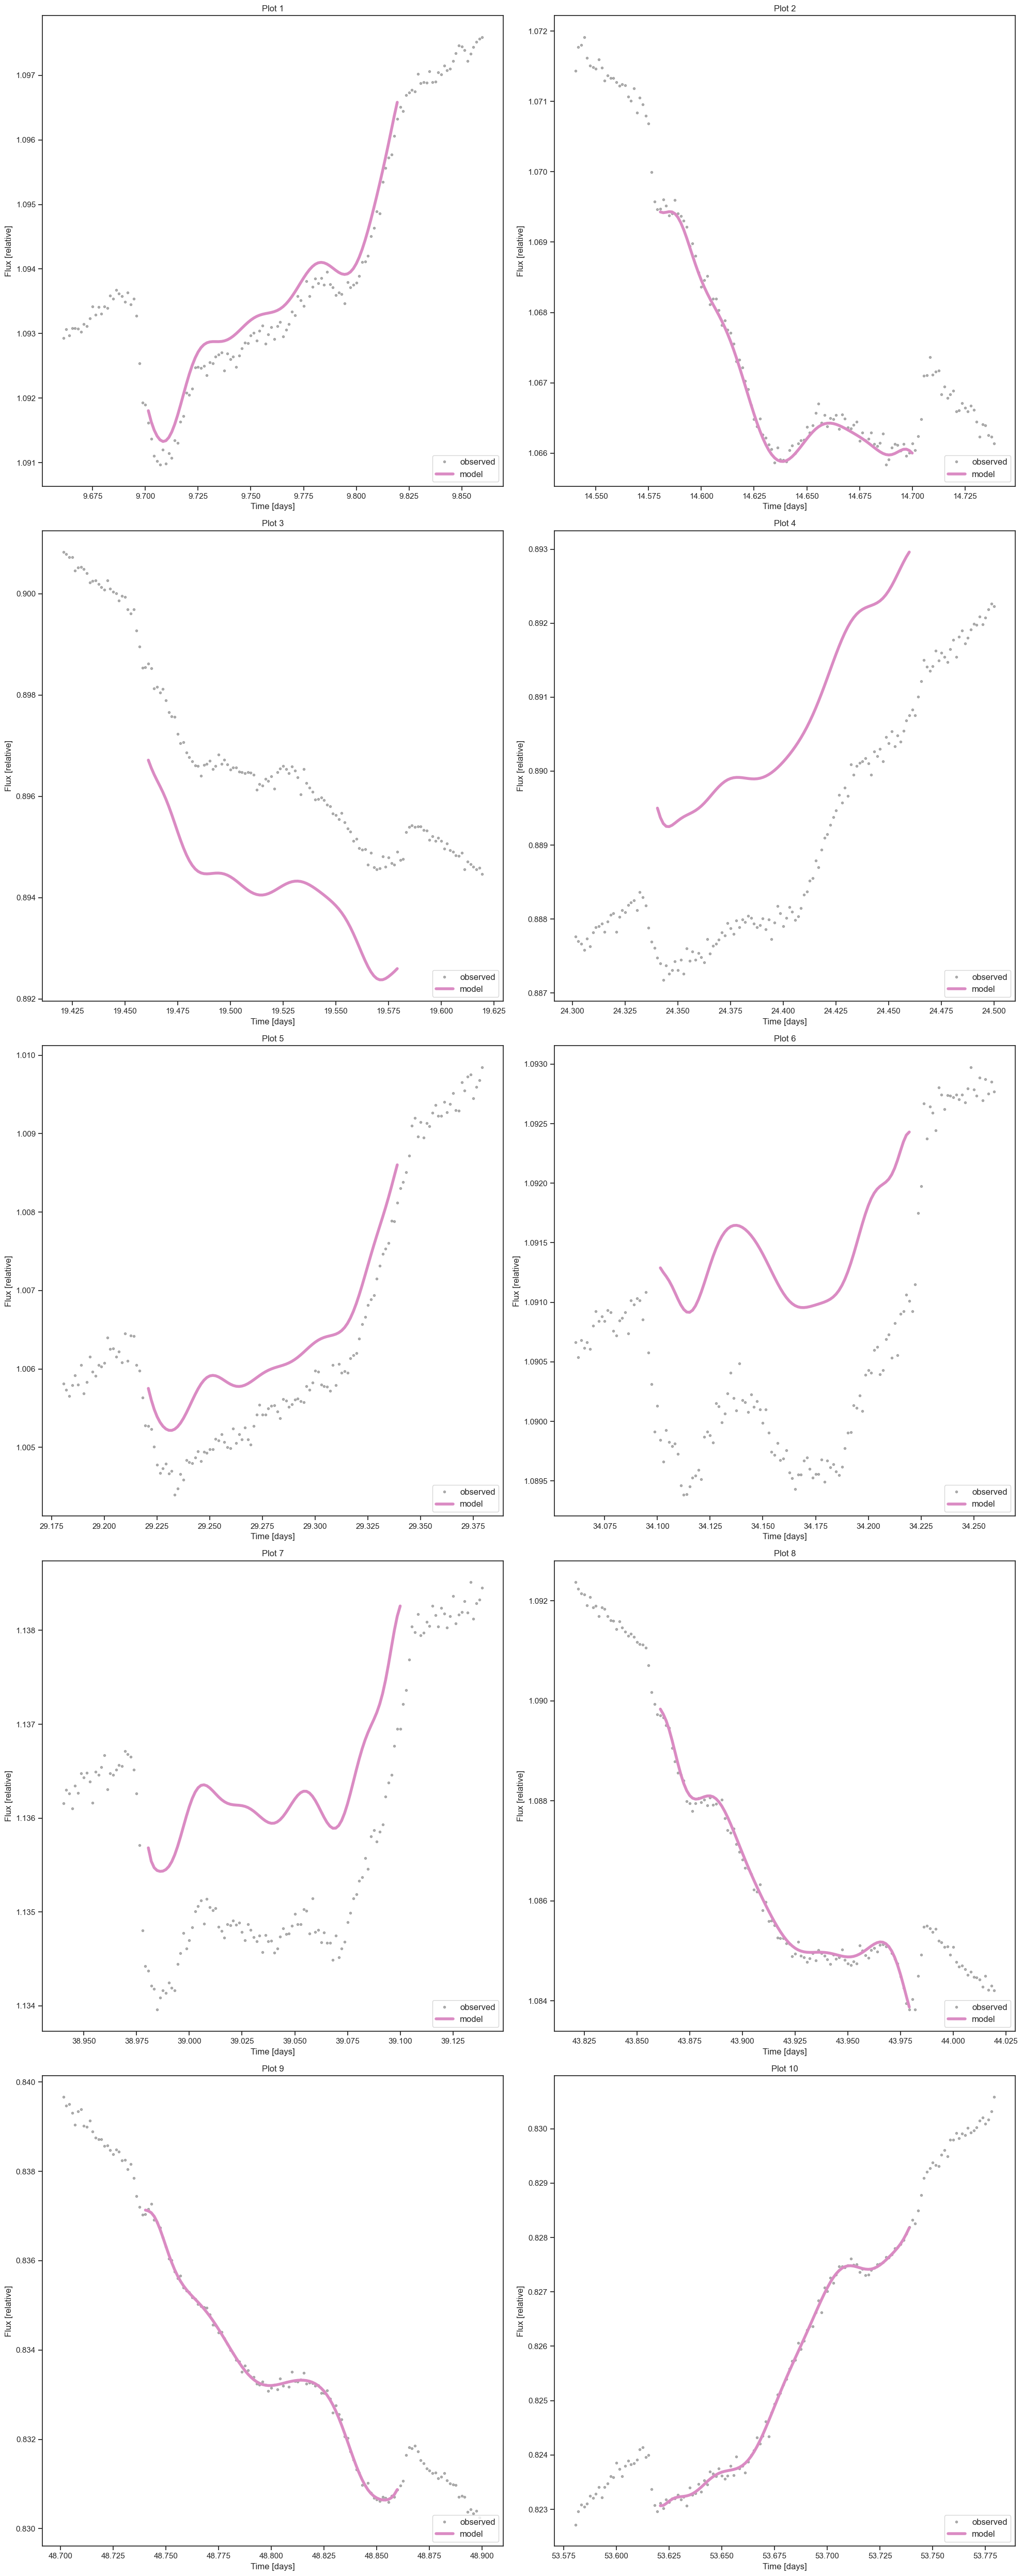

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 50))  # Create a large figure to hold all subplots

for n in range(10):
    plt.subplot(5, 2, n+1)  # Create a 5x2 grid of subplots
    
    # Plot observed data
    idx = (t > planet.t0.eval()+(i+n)*planet.porb.eval()-0.1) & (t < planet.t0.eval()+(i+n)*planet.porb.eval()+0.1)
    plt.plot(t[idx], flux_obs[idx], "k.", alpha=0.3, label="observed")
    
    # Plot model data
    idx = (t_ > planet.t0.eval()+(i+n)*planet.porb.eval()-0.1) & (t_ < planet.t0.eval()+(i+n)*planet.porb.eval()+0.1)
    plt.plot(t_[idx], np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0)[idx], "C6", label="model", alpha=1, lw=4)
    
    plt.legend(fontsize=12, loc="lower right")
    plt.title(f"Plot {n+1}")
    plt.xlabel("Time [days]")
    plt.ylabel("Flux [relative]")

plt.tight_layout()
plt.show()